# STRATA — Supervisión estadística de un agente LLM de trading

**Trabajo Fin de Grado · Matemáticas y Ciencia de Datos · Raquel García**

Este cuaderno es el documento canónico de la tesis: se ejecuta de arriba a abajo y
reproduce todas las cifras de la memoria. Estudia un único activo, **SPY** (ETF del
S&P 500), sobre la ventana out-of-sample (OOS) `2024-10-01 → 2026-05-11`. El panel
multi-activo y los casos de fallo viven en un cuaderno aparte.

La pregunta que se contesta no es *"¿predigo el mercado?"* sino *"¿puedo supervisar
estadísticamente a un agente que decide, y rescatarlo cuando pierde?"*. STRATA no
predice retornos: es una función que toma la decisión del agente y el estado del
mercado y devuelve una decisión supervisada.

Carga de caché lo que es caro de regenerar —las decisiones del agente LLM y los
modelos calibrados— y **recalcula todo lo demás** dentro del cuaderno: posteriores
del HMM, volatilidad GARCH, detectores, backtests y contrastes. Cada cifra se
acompaña de su test y aparece en una tabla cruda para que pueda comprobarse.

## §0. Preámbulo

Fijamos la semilla global y las rutas, y registramos el *hash* de las dos cachés de
las que dependemos. Si esas cachés cambian, las cifras cambian: el hash las sella.

**Glosario de notación** (el mismo símbolo significa lo mismo en todo el cuaderno y
en la memoria):

| Símbolo | Código | Significado |
|---|---|---|
| $r_t=\log(P_t/P_{t-1})$ | `r` | log-retorno diario |
| $y_t=\mathbf{1}\{r_{t+1}>0\}$ | `y` | verdad de campo direccional |
| $s_t\in\{\text{Calma},\text{Estrés},\text{Crisis}\}$ | `regime` | estado latente del HMM |
| $\gamma^f_t(s)=P(s_t=s\mid x_{1:t})$ | `gamma` | posterior **filtrado** (causal) |
| $\sigma_t$ | `sigma` | volatilidad condicional GARCH anualizada |
| $\text{RAM}_t,\text{PSA}_t,\text{GSO}_t$ | `ram,psa,gso` | scores de los tres detectores |
| $w_t\in[-1,1]$ | `final_size` | posición supervisada del día $t$ |
| $\pi_t=w_t\,r_{t+1}$ | `net_return` | P&L causal (`signal_lag=1`) |

In [1]:
import glob
import hashlib
import json
import os
import pickle
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# El notebook vive en notebooks/; la raíz del proyecto es el padre. La ponemos en
# el path e instalamos como cwd para que config y las cachés resuelvan igual que en CLI.
_ROOT = Path.cwd() if (Path.cwd() / "config.py").exists() else Path.cwd().parent
sys.path.insert(0, str(_ROOT))
os.chdir(_ROOT)

import config
from config import CACHE_AGENT_DIR, CACHE_MODELS_DIR, STRATA_OOS_START, set_seeds
from core import data, features, metrics
from core.backtest import run_backtest
from core.stats import mcnemar_test, sign_test

set_seeds(config.SEED)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

TICKER = "SPY"
# DATA_END = último parquet de precios cacheado para SPY (sin red). Cubre el OOS del
# agente más los días necesarios para el retorno t+1 del último día decidido.
_spy_parquets = sorted(glob.glob(str(config.DATA_DIR / f"{TICKER}_{config.CALIBRATION_START}_*.parquet")))
DATA_END = _spy_parquets[-1].rsplit("_", 1)[1].replace(".parquet", "")


def _hash_dir(path: Path, pattern: str = "*") -> str:
    h = hashlib.sha256()
    for fp in sorted(path.glob(pattern)):
        if fp.is_file():
            h.update(fp.name.encode())
            h.update(fp.read_bytes())
    return h.hexdigest()[:16]


print(f"seed = {config.SEED}")
print(f"hash cache/agent/{TICKER} = {_hash_dir(CACHE_AGENT_DIR / TICKER)}")
print(f"hash cache/models        = {_hash_dir(CACHE_MODELS_DIR)}")
print(f"calibración: {config.CALIBRATION_START} → {config.CALIBRATION_END}")
print(f"OOS:         {STRATA_OOS_START} → (cierre del agente)")

seed = 42


hash cache/agent/SPY = e1790da591004a5d
hash cache/models        = 5c01cd98295dfb4c
calibración: 2000-01-01 → 2024-09-30
OOS:         2024-10-01 → (cierre del agente)


# Parte I — Marco y datos

## §1. Marco matemático

Las cuatro piezas y los contrastes que usaremos. Cada objeto se enuncia aquí y se
*usa* en las secciones siguientes.

**HMM gaussiano de régimen.** Modelamos la observación diaria $x_t=(r_t,\,\mathrm{RV}^{21}_t)$
—log-retorno y volatilidad realizada a 21 días anualizada— como emisión de una
cadena de Markov latente de tres estados con matriz de transición $A=(a_{ij})$ y
emisiones $\mathcal{N}(\mu_k,\Sigma_k)$. El régimen relevante en OOS es el
**posterior filtrado**
$$\gamma^f_t(s)=P(s_t=s\mid x_{1:t}),$$
que solo usa información hasta $t$. Es deliberadamente distinto del *suavizado*
$P(s_t\mid x_{1:T})$ de `hmmlearn`, que usaría el futuro y contaminaría el OOS con
look-ahead (Rabiner 1989; Hamilton 1989).

**GARCH(1,1) con innovaciones Student-$t$.** La volatilidad condicional sigue
$$\sigma_t^2=\omega+\alpha\,\varepsilon_{t-1}^2+\beta\,\sigma_{t-1}^2,\qquad \varepsilon_t=\sigma_t z_t,\ z_t\sim t_\nu.$$

> **Proposición (estacionariedad débil).** Si $\alpha+\beta<1$ y $\omega>0$, el
> proceso tiene varianza incondicional finita $\bar\sigma^2=\omega/(1-\alpha-\beta)$.
>
> *Demostración.* Tomando esperanzas en la recursión y usando $\mathbb{E}[\varepsilon_{t-1}^2]=\mathbb{E}[\sigma_{t-1}^2]$
> y estacionariedad $\mathbb{E}[\sigma_t^2]=\mathbb{E}[\sigma_{t-1}^2]=\bar\sigma^2$:
> $\bar\sigma^2=\omega+(\alpha+\beta)\bar\sigma^2$, de donde $\bar\sigma^2(1-\alpha-\beta)=\omega$.
> El cociente es positivo y finito si y solo si $\alpha+\beta<1$. $\;\blacksquare$

Verificaremos $\alpha+\beta<1$ con los parámetros calibrados (Bollerslev 1986, 1987).

**BOCPD.** La detección bayesiana online de puntos de cambio (Adams & MacKay 2007)
mantiene el posterior de la *longitud de racha* $r_t^{\mathrm{rl}}$ sobre el sizing
del agente, con tasa de riesgo (*hazard*) $H$. El score de PSA es la masa de
probabilidad de racha corta: sube cuando el agente cambia bruscamente de criterio.

**Los tres detectores.** Sobre la terna del agente $(\text{acción}_t,\text{size}_t,\text{conf}_t)$
y el estado de mercado:
- **RAM** (régimen): $\text{RAM}_t=\sum_{s\in\mathcal{I}(\text{acción}_t)}\gamma^f_t(s)$, masa
  filtrada sobre los regímenes *incompatibles* con la acción. La política es
  simétrica con el *leverage effect* (Black 1976; Christie 1982): en Calma se permite
  largo, en Crisis corto, en Estrés ambos.
- **PSA** (coherencia temporal): score BOCPD sobre el sizing.
- **GSO** (volatilidad): exceso del sizing sobre la banda $v^\*/\sigma_t$.

**Intervención — override variante C.** Si RAM marca severidad media/alta, la posición
se reorienta hacia el régimen con la banda de volatilidad: $w_t=\mathrm{signo}_\text{régimen}\cdot
\min(1,v^\*/\sigma_t)$.

**Contrastes.** Sign test binomial (M5 vs azar), McNemar pareado (M8 vs M5),
Diebold-Mariano y TOST (M10 vs M8), bootstrap estacionario para el IC del $\Delta$Sharpe
(Politis-Romano 1994) y Deflated Sharpe (López de Prado 2014). El backtest es causal:
$\pi_t=w_t\,r_{t+1}$ con `signal_lag=1`.

## §2. Datos y barrera temporal

Cargamos el precio de SPY (cacheado, sin red) y las decisiones del agente. De los
precios recalculamos $r_t$ y $\mathrm{RV}^{21}_t$, y de ahí el posterior **filtrado**
del HMM y la volatilidad GARCH. Antes de usar nada, dos controles que **abortan** el
cuaderno si se viola la causalidad: el backtest debe cumplir $\pi$ en $t$ = $w_{t-1}r_t$
(la posición de ayer gana el retorno de hoy), y la calibración no puede solapar el OOS.

La serie de precios llega más allá del último día que decide el agente: esos días
extra no se usan como observaciones, solo aportan el retorno $r_{t+1}$ del último día
supervisado. Por eso el OOS *de precios* (≈417 días) es algo más largo que el OOS *con
decisión del agente* (401 días), que es el que entra en `master`.

In [2]:
prices = data.load_market_data(TICKER, config.CALIBRATION_START, DATA_END)
ret = features.log_returns(prices["Close"])
rv21 = features.realized_vol_annualized(ret, window=21)
feat_df = pd.concat([ret.rename("r"), rv21.rename("rv")], axis=1).dropna()

hmm = pickle.load(open(CACHE_MODELS_DIR / "hmm.pkl", "rb"))
garch = pickle.load(open(CACHE_MODELS_DIR / f"garch_{TICKER}.pkl", "rb"))

# Posterior FILTRADO causal sobre toda la serie: la fila t solo usa x_{1:t}.
gamma = hmm.predict_proba_filtered(feat_df.to_numpy())
gamma_df = pd.DataFrame(gamma, index=feat_df.index, columns=["Calma", "Estrés", "Crisis"])

# OOS y volatilidad GARCH (forecast a un paso; sigma_t ya es causal, no usa r_t).
oos_ret = ret[ret.index >= pd.Timestamp(STRATA_OOS_START)]
sigma = garch.forecast_path(oos_ret)

print(f"precios SPY: {prices.index.min().date()} → {prices.index.max().date()}  ({len(prices)} días)")
print(f"features tras warm-up: {feat_df.index.min().date()} → {feat_df.index.max().date()}")
print(f"OOS de precios: {oos_ret.index.min().date()} → {oos_ret.index.max().date()}  ({len(oos_ret)} días)")
print("(El OOS del agente termina antes; los precios se extienden solo para el r_{t+1} del último día.)")
feat_df.tail(3)

precios SPY: 2000-01-03 → 2026-06-05  (6646 días)
features tras warm-up: 2000-02-02 → 2026-06-05
OOS de precios: 2024-10-01 → 2026-06-05  (421 días)
(El OOS del agente termina antes; los precios se extienden solo para el r_{t+1} del último día.)


,r,rv
date,,
2026-06-03,-0.0070,0.0985
2026-06-04,0.0038,0.0965
2026-06-05,-0.0261,0.1294


In [3]:
# CONTROL 1 — causalidad del backtest: la posición de t gana el retorno de t+1, no el de t.
_r = pd.Series([0.0, 0.10, -0.05, 0.0], index=pd.date_range("2024-10-01", periods=4, freq="B"))
_w = pd.Series([1.0, 0.0, 0.0, 0.0], index=_r.index)
_bt = run_backtest(_r, _w, cost_bps=0.0, signal_lag=1)
assert abs(_bt["gross_return"].iloc[1] - 0.10) < 1e-12, "LOOK-AHEAD: el peso de t no gana r_{t+1}"
assert _bt["gross_return"].iloc[0] == 0.0, "LOOK-AHEAD: el peso de t gana r_t (bug histórico)"

# CONTROL 2 — barrera temporal calibración / OOS (sin solape; OOS tras el cutoff del LLM).
calib_idx = feat_df.index[feat_df.index <= pd.Timestamp(config.CALIBRATION_END)]
oos_idx = feat_df.index[feat_df.index >= pd.Timestamp(STRATA_OOS_START)]
assert calib_idx.max() < pd.Timestamp(STRATA_OOS_START), "La calibración invade el OOS"
assert len(calib_idx.intersection(oos_idx)) == 0, "Solape calibración/OOS"
th_meta = json.load(open(CACHE_MODELS_DIR / "strata_thresholds.json"))
assert th_meta["calibration_window"][1] == config.CALIBRATION_END, "Umbrales no calibrados ex-ante"
# El OOS arranca tras el cutoff de DeepSeek V3 (jul-oct 2024): elimina contaminación del LLM.
assert pd.Timestamp(STRATA_OOS_START) >= pd.Timestamp("2024-10-01"), "OOS antes del cutoff del LLM"
print("Controles de no-look-ahead superados: causalidad t→t+1, barrera temporal y cutoff del LLM.")

Controles de no-look-ahead superados: causalidad t→t+1, barrera temporal y cutoff del LLM.


# Parte II — Calibración

Todo lo que el sistema *aprende* se fija sobre el histórico `2000-01-01 → 2024-09-30`
(24 años) y queda congelado en OOS. No hay re-ajuste fuera de muestra.

## §3. Parámetros de los modelos base

Mostramos los parámetros calibrados tal cual, comprobamos la estacionariedad
$\alpha+\beta<1$ del GARCH y exhibimos la **correspondencia régimen → signo** que
justifica la política de RAM: el sentido permitido por régimen no se introduce a
mano, se **deriva** del signo de la media de retornos por régimen en calibración.

In [4]:
# Matriz de transición y etiquetas del HMM (ordenado por volatilidad emisora).
A = pd.DataFrame(hmm.transition_matrix,
                 index=list(hmm.state_labels.values()),
                 columns=list(hmm.state_labels.values()))
print("Matriz de transición A (filas = desde, columnas = hacia):")
A

Matriz de transición A (filas = desde, columnas = hacia):


,Calma,Estrés,Crisis
Calma,0.9821,0.0177,0.0002
Estrés,0.0193,0.9729,0.0078
Crisis,0.0000,0.0217,0.9783


In [5]:
# Parámetros GARCH(1,1)-t y check de estacionariedad alpha+beta<1.
p = garch.params
garch_tab = pd.Series({"mu": p.mu, "omega": p.omega, "alpha": p.alpha, "beta": p.beta,
                       "nu": p.nu, "alpha+beta": p.alpha + p.beta})
print(f"GARCH estacionario (alpha+beta<1): {p.is_stationary()}")
print(f"varianza incondicional anualizada ~ {np.sqrt(p.omega/(1-p.alpha-p.beta))/100*np.sqrt(252):.3f}")
print(f"BOCPD hazard = {config.BOCPD_HAZARD:.4g}  (≈ 1 cambio/año bursátil)")
garch_tab.to_frame("valor")

GARCH estacionario (alpha+beta<1): True
varianza incondicional anualizada ~ 0.327
BOCPD hazard = 0.004  (≈ 1 cambio/año bursátil)


,valor
mu,0.0880
omega,0.0148
alpha,0.1276
beta,0.8689
nu,6.3894
alpha+beta,0.9965


In [6]:
# Correspondencia régimen → signo en CALIBRACIÓN. RAM fija el sentido permitido por el
# SIGNO de la media de retorno por régimen (no su magnitud). Acompañamos cada media de un
# IC95 bootstrap estacionario (Politis-Romano), que respeta la dependencia serial, y de la
# proporción de días positivos: ambas cuentan historias distintas por la asimetría.
from core.stats import stationary_bootstrap_ci

calib_feat = feat_df.loc[feat_df.index <= pd.Timestamp(config.CALIBRATION_END)]
calib_states = hmm.predict_states(calib_feat.to_numpy())
reg_tab = pd.DataFrame({"r": calib_feat["r"].to_numpy(), "estado": calib_states})
reg_tab["régimen"] = reg_tab["estado"].map(hmm.state_labels)
filas = []
for reg in ["Calma", "Estrés", "Crisis"]:
    rr = reg_tab.loc[reg_tab["régimen"] == reg, "r"].to_numpy()
    lo, hi, mean = stationary_bootstrap_ci(rr, np.mean, n=2000, seed=config.SEED)
    filas.append({"régimen": reg, "media r": mean, "IC95 media": f"[{lo:+.5f}, {hi:+.5f}]",
                  "media≠0": not (lo <= 0 <= hi), "% días +": (rr > 0).mean(),
                  "std": rr.std(), "n": len(rr),
                  "sentido RAM": "+ (long)" if mean > 0 else "− (short)"})
resumen = pd.DataFrame(filas).set_index("régimen")
print("RAM usa el SIGNO de la media por régimen. Solo Calma tiene media significativamente")
print("positiva (IC excluye 0). En Crisis la media es negativa por la ASIMETRÍA de las caídas")
print("(leverage effect): ~50% de días positivos pero los negativos son mayores (std alta). A")
print("resolución diaria su IC roza el cero, así que 'Crisis → short' es un prior direccional")
print("DÉBIL; el valor de RAM en Crisis es sobre todo frenar la exposición larga en alta vol.")
resumen

RAM usa el SIGNO de la media por régimen. Solo Calma tiene media significativamente
positiva (IC excluye 0). En Crisis la media es negativa por la ASIMETRÍA de las caídas
(leverage effect): ~50% de días positivos pero los negativos son mayores (std alta). A
resolución diaria su IC roza el cero, así que 'Crisis → short' es un prior direccional
DÉBIL; el valor de RAM en Crisis es sobre todo frenar la exposición larga en alta vol.


,media r,IC95 media,media≠0,% días +,std,n,sentido RAM
régimen,,,,,,,
Calma,0.0006,"[+0.00045, +0.00082]",True,0.5675,0.0059,2712,+ (long)
Estrés,0.0002,"[-0.00022, +0.00061]",False,0.5324,0.0109,2530,+ (long)
Crisis,-0.0004,"[-0.00141, +0.00058]",False,0.5083,0.0235,962,− (short)


### Selección del número de regímenes $K$ (decisión de calibración)

¿Por qué **tres** estados y no dos? Es una decisión de **calibración** —se toma aquí, sobre
2000–2024, antes de ver el OOS— con dos criterios que no miran el futuro:

1. **Verosimilitud fuera de muestra** (validación temporal *dentro* de la calibración: ajustar en
   el pasado, puntuar el bloque siguiente). Es el criterio honesto frente a BIC/AIC, que premian
   más estados por la mala especificación gaussiana (colas pesadas).
2. **Estructura económica**: la tabla régimen→signo de arriba ya muestra tres regímenes
   distintos en **signo de retorno** (Calma $+$, Estrés $\approx0$, Crisis $-$) y en
   **volatilidad** creciente.

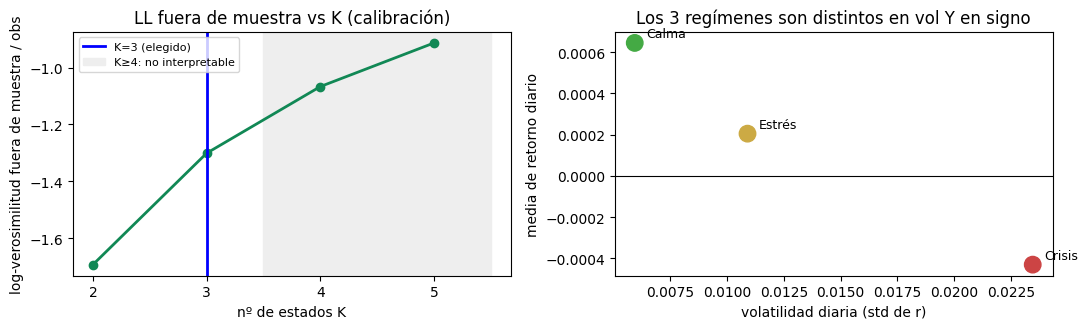

Log-verosimilitud fuera de muestra /obs:  K=2: -1.693   K=3: -1.301   K=4: -1.067   K=5: -0.913
Δ(K3−K2) = +0.392/obs (grande: el 3er estado mejora MUCHO los datos no vistos).
La LL CRECE con K (la gaussiana mal especificada compra ajuste con más estados), así que NO
'selecciona' K=3 — solo descarta K=2 con holgura. Acotamos a K∈{2,3} por INTERPRETABILIDAD:
Calma/Estrés/Crisis son regímenes nombrables; K≥4 subdivide la vol sin relato económico.


In [7]:
from core.hmm import RegimeHMM

# Verosimilitud FUERA DE MUESTRA por nº de estados (validación temporal en la propia calibración).
calib_X = calib_feat.to_numpy()
def heldout_ll(K, folds=(0.5, 0.6, 0.7, 0.8, 0.9)):
    n = len(calib_X); lls = []
    for i, s in enumerate(folds):
        a = int(s * n); b = int((s + 0.1) * n) if i < len(folds) - 1 else n
        h = RegimeHMM(n_states=K, seed=config.SEED).fit(calib_X[:a])
        lls.append(float(h.model.score(h._standardize(calib_X[a:b])) / (b - a)))
    return float(np.mean(lls))
ll = {K: heldout_ll(K) for K in (2, 3, 4, 5)}

import matplotlib.pyplot as plt
mu = resumen["media r"].to_numpy(); sd = resumen["std"].to_numpy(); col = ["#4a4", "#ca4", "#c44"]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
Ks = list(ll)
ax[0].plot(Ks, [ll[k] for k in Ks], "o-", color="#185", lw=2)
ax[0].axvline(3, color="blue", lw=2, label="K=3 (elegido)")
ax[0].axvspan(3.5, 5.5, color="#eee", label="K≥4: no interpretable")
ax[0].set_xticks(Ks); ax[0].set_xlabel("nº de estados K")
ax[0].set_ylabel("log-verosimilitud fuera de muestra / obs")
ax[0].set_title("LL fuera de muestra vs K (calibración)"); ax[0].legend(fontsize=8)
ax[1].scatter(sd, mu, c=col, s=140, zorder=3)
for i, nm in enumerate(["Calma", "Estrés", "Crisis"]):
    ax[1].annotate(nm, (sd[i], mu[i]), textcoords="offset points", xytext=(8, 4), fontsize=9)
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set_xlabel("volatilidad diaria (std de r)"); ax[1].set_ylabel("media de retorno diario")
ax[1].set_title("Los 3 regímenes son distintos en vol Y en signo")
plt.tight_layout(); plt.show()

print("Log-verosimilitud fuera de muestra /obs:  " + "   ".join(f"K={k}: {ll[k]:+.3f}" for k in Ks))
print(f"Δ(K3−K2) = {ll[3] - ll[2]:+.3f}/obs (grande: el 3er estado mejora MUCHO los datos no vistos).")
print("La LL CRECE con K (la gaussiana mal especificada compra ajuste con más estados), así que NO")
print("'selecciona' K=3 — solo descarta K=2 con holgura. Acotamos a K∈{2,3} por INTERPRETABILIDAD:")
print("Calma/Estrés/Crisis son regímenes nombrables; K≥4 subdivide la vol sin relato económico.")

**Decisión (calibración): $K=3$.** El tercer estado mejora claramente la descripción de datos
no vistos respecto a dos, y los tres regímenes son económicamente distintos (panel derecho:
Calma = baja vol/drift $+$; Estrés = vol media/drift $\approx0$; Crisis = alta vol/drift $-$).
Cautela honesta: la verosimilitud no "selecciona" $K=3$ —es monótona en $K$— sino que descarta
$K=2$; el tope en 3 es por **interpretabilidad**, no por ajuste. En §12 (Parte V) comprobamos que
el OOS no contradice esta elección.

### El régimen del HMM sobre el precio (figura 06b — dual-panel)

Reproducimos la figura 06b del proyecto (estilo `viz/comparison.py`): arriba el precio de SPY con
**bandas verticales por régimen**, abajo una **barra compacta del régimen activo**. La
clasificación es la **decodificación de Viterbi** (`predict_states`) —la secuencia de régimen más
probable, *descriptiva ex-post*; nótese que para *operar* RAM usa el posterior **filtrado**
causal, no Viterbi—. Primero sobre la **calibración** (2000–2024-09, donde se ajustó el HMM) y
debajo sobre el **TEST/OOS** (2024-10→cierre), para ver qué regímenes ocurren en cada periodo.

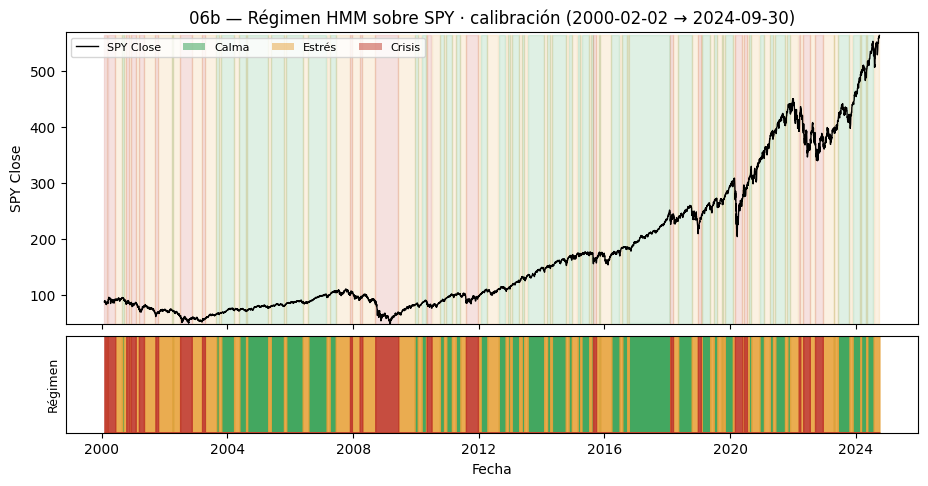

Ocupación de régimen: Calma 43.7%  Estrés 40.8%  Crisis 15.5%


In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

REGIME_COLOR = {"Calma": "#2e9e4f", "Estrés": "#e8a33d", "Crisis": "#c0392b"}
_STATE_LBL = {0: "Calma", 1: "Estrés", 2: "Crisis"}


def plot_regimes_06b(close, feats, title):
    # Figura 06b: dual-panel precio + régimen Viterbi (predict_states), estilo viz/comparison.py.
    states = pd.Series(hmm.predict_states(feats.to_numpy()), index=feats.index)
    price = close.reindex(states.index).ffill()
    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(11, 5.2), sharex=True,
                                         gridspec_kw={"height_ratios": [3, 1], "hspace": 0.06})
    ax_top.plot(price.index, price.values, color="black", linewidth=1.0)
    y_min, y_max = float(price.min()), float(price.max())
    for st in (0, 1, 2):
        mask = (states == st).to_numpy()
        ax_top.fill_between(states.index, y_min, y_max, where=mask,
                            color=REGIME_COLOR[_STATE_LBL[st]], alpha=0.15, step="post")
    ax_top.set_ylim(y_min * 0.99, y_max * 1.01); ax_top.set_ylabel("SPY Close"); ax_top.set_title(title)
    handles = [plt.Line2D([0], [0], color="black", lw=1.0, label="SPY Close")] + \
        [Patch(facecolor=REGIME_COLOR[_STATE_LBL[s]], alpha=0.5, label=_STATE_LBL[s]) for s in (0, 1, 2)]
    ax_top.legend(handles=handles, fontsize=8, loc="upper left", ncol=4)
    for st in (0, 1, 2):
        ax_bot.fill_between(states.index, 0, (states == st).astype(int).to_numpy(),
                            color=REGIME_COLOR[_STATE_LBL[st]], alpha=0.9, step="post")
    ax_bot.set_ylim(0, 1); ax_bot.set_yticks([]); ax_bot.set_ylabel("Régimen", fontsize=9); ax_bot.set_xlabel("Fecha")
    plt.show()  # el gridspec (hspace) ya separa los paneles; tight_layout avisa con fill_between
    occ = states.value_counts(normalize=True).sort_index()
    print("Ocupación de régimen: " + "  ".join(f"{_STATE_LBL[k]} {occ.get(k, 0):.1%}" for k in (0, 1, 2)))


# CALIBRACIÓN 2000–2024-09 (el periodo donde se ajustó el HMM).
plot_regimes_06b(prices["Close"], calib_feat,
                 f"06b — Régimen HMM sobre SPY · calibración ({calib_feat.index[0].date()} → {calib_feat.index[-1].date()})")

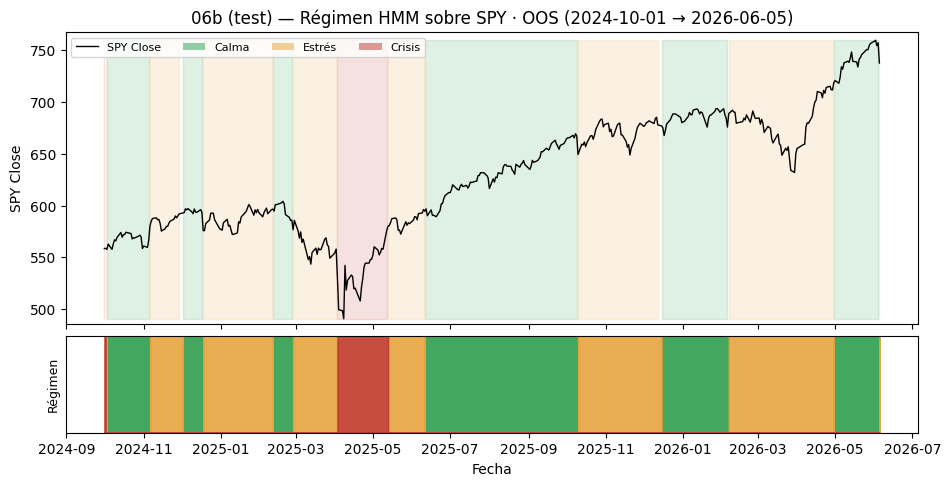

Ocupación de régimen: Calma 45.6%  Estrés 47.7%  Crisis 6.7%


In [9]:
# TEST / OOS 2024-10 → cierre (el régimen que ocurre en el periodo de evaluación).
oos_feat = feat_df.loc[feat_df.index >= pd.Timestamp(STRATA_OOS_START)]
plot_regimes_06b(prices["Close"], oos_feat,
                 f"06b (test) — Régimen HMM sobre SPY · OOS ({oos_feat.index[0].date()} → {oos_feat.index[-1].date()})")

## §4. De dónde salen los umbrales (metodología rigurosa)

**Principio rector (siempre).** Toda decisión de umbral en STRATA se toma **ex-ante sobre la
calibración 2000–2024, ANTES de ver el OOS**. Es la disciplina que blinda contra el p-hacking y
la que el tutor exige: ningún corte se elige porque "mejora la curva".

**PSA y GSO — percentiles del score en calibración.** Son **detectores de alarma para patologías
raras**: PSA marca que el agente pega un *volantazo estructural* en su sizing; GSO que se
*sobreexpone* brutalmente para la volatilidad del día. Por eso su severidad se mapea a percentiles
**altos**: low = P95, medium = P99, high = máximo. El override dispara en severidad ≥ medium =
**P99 = el 1 % más extremo** de la calibración. La elección de P99 no es a ojo: como se ve abajo,
las distribuciones tienen **suelo plano y cola larga** —el score vive pegado a su mínimo en el
90–95 % de los días y solo explota en la cola—; **P99 es el codo donde empieza la anomalía real**,
no el ruido de fondo. Un detector de alarma debe ser conservador por diseño.

In [10]:
th = json.load(open(CACHE_MODELS_DIR / "strata_thresholds.json"))
def _dist(name):
    return pd.Series(th[name]["score_distribution"], name=name)
umbrales = pd.concat([_dist("psa"), _dist("gso")], axis=1)
print(f"Ventana de calibración de umbrales PSA/GSO: {th['calibration_window']}  (n={th['psa']['n_obs']})")
umbrales

Ventana de calibración de umbrales PSA/GSO: ['2000-01-01', '2024-09-30']  (n=6025)


,psa,gso
p50,0.0049,0.4245
p75,0.0056,1.0055
p90,0.0087,1.7167
p95,0.0229,2.3706
p99,0.6472,5.5653
max,1.0000,10.3025


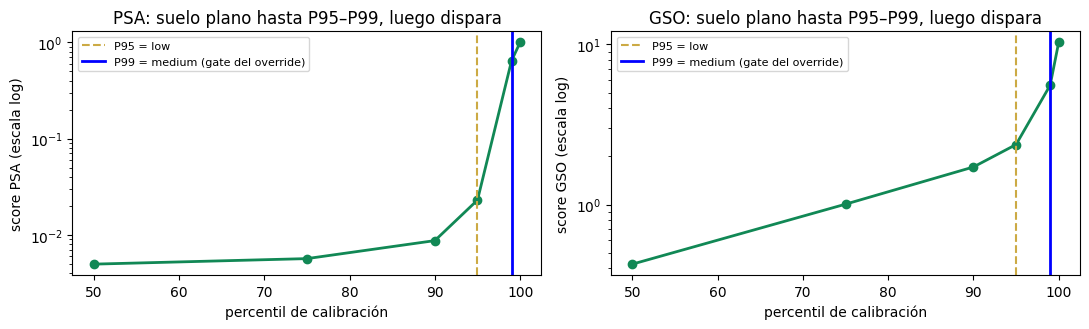

PSA: el score (prob. de change-point) vive en ~0.005 el 90% de los días; solo en P99 sube a 0.65.
GSO: el score de sobreexposición tiene cola larga (P99≈5.6, max≈10.3); P99 corta solo lo extremo.


In [11]:
import matplotlib.pyplot as plt

# Perfil de la distribución del score (cuantiles de calibración): muestra el suelo plano y
# la cola, y por qué el gate del override se pone en P99 (donde empieza la anomalía real).
pcts = [50, 75, 90, 95, 99, 100]
def _profile(name):
    d = th[name]["score_distribution"]
    return [d["p50"], d["p75"], d["p90"], d["p95"], d["p99"], d["max"]]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for a, name, ttl in [(ax[0], "psa", "PSA"), (ax[1], "gso", "GSO")]:
    a.plot(pcts, _profile(name), "o-", color="#185", lw=2)
    a.set_yscale("log")
    a.axvline(95, color="#ca4", lw=1.5, ls="--", label="P95 = low")
    a.axvline(99, color="blue", lw=2, label="P99 = medium (gate del override)")
    a.set_xlabel("percentil de calibración"); a.set_ylabel(f"score {ttl} (escala log)")
    a.set_title(f"{ttl}: suelo plano hasta P95–P99, luego dispara"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("PSA: el score (prob. de change-point) vive en ~0.005 el 90% de los días; solo en P99 sube a 0.65.")
print("GSO: el score de sobreexposición tiene cola larga (P99≈5.6, max≈10.3); P99 corta solo lo extremo.")

**¿Y si relajáramos los umbrales para que disparen más?** Lo probamos explícitamente (cuaderno
de experimentos, §E4): bajar PSA/GSO hasta P50 hace que **PSA dispare en ~193/401 días, pero NO
mejora el acierto direccional** (Δacc = 0; McNemar trivial $b=c=0$) —PSA solo encoge magnitud,
nunca voltea el signo—; y **GSO no llega a disparar ni así**, porque su score es $\approx0$ en todo
el OOS (el agente nunca se sobreexpone). El único Sharpe que se mueve (+0.07 en PSA-P50) **no es
significativo** (IC del ΔSharpe incluye 0) y vendría de reducir exposición, no de acertar más.
**Conclusión: P95/P99 ex-ante no solo es defendible —es óptimo—; relajarlo no aporta nada, y elegir
el corte por el Sharpe del OOS sería look-ahead.** Los umbrales se quedan donde la calibración los
puso. (PSA/GSO son **cortafuegos**; el motor direccional de la supervisión es RAM.)

RAM necesita su **propia** metodología: su score es una **masa de probabilidad de régimen**
$P(\text{régimen contrario a la acción})$, no un score de anomalía. Para el agente —sesgado a
corto— el override dispara y voltea a largo cuando $P(\text{Calma})$ es alta. Calibramos el gate
$\tau$ ex-ante sobre 2000–2024-09 (sin agente ni OOS) con dos hechos del histórico:

1. **El score es bimodal.** El posterior filtrado es cuasi-determinista: casi toda la masa de
   $P(\text{Calma})$ está en $\approx0$ o $\approx1$, con un **valle vacío en el medio**.
   Cualquier umbral en ese valle separa "régimen coherente/ambiguo" (no actuar) de "régimen
   fuertemente contrario" (actuar) **casi sin días en la frontera**.
2. **El acierto direccional es plano.** El acierto de "largo" condicionado a $P(\text{Calma})\ge\tau$
   es ≈ constante para cualquier $\tau\in[0.3,0.9]$: mover el corte ahí dentro no cambia ni los
   días que disparan ni el acierto.

Por eso adoptamos el **gate paramétrico-libre $\tau=0.5$** (regla de mayoría: intervenir cuando el
régimen contrario es el **más probable**, $P\ge0.5$). Tiene **varianza de estimación nula** —no se
estima de los datos, es el punto de Bayes— y, por la bimodalidad + el acierto plano, el resultado
es **robusto a su posición exacta** (§6 lo confirma sobre el OOS).

*Cautela honesta:* medir "acierto $>0.5$ absoluto" estaría confundido por el **drift** (SPY sube el
54 % de los días → "largo" acierta $>0.5$ **siempre**, haya o no señal). Por eso el gate no calibra
contra el 0.5 absoluto del acierto, sino que **separa la masa bimodal del score**: actuar solo
cuando el régimen contrario **domina** la probabilidad. `ram_thresholds = (τ/2, τ, 0.70)`: el *gate*
del override (M8) **y** del reduce (M7) es `medium`$=\tau=0.5$ —ambos disparan cuando `score`$\ge\tau$—.
`low`$=0.25$ y `high`$=0.70$ **no intervienen**: son la infraestructura de tres niveles compartida con
PSA/GSO (donde sí salen de percentiles $P_{95}/P_{99}/\max$) y aquí solo etiquetan severidad en la
tabla de §6. RAM es, de facto, un detector de **un único corte $\tau$**; la tupla conserva la firma
común de los tres detectores sin añadir grados de libertad sobre el P&L.

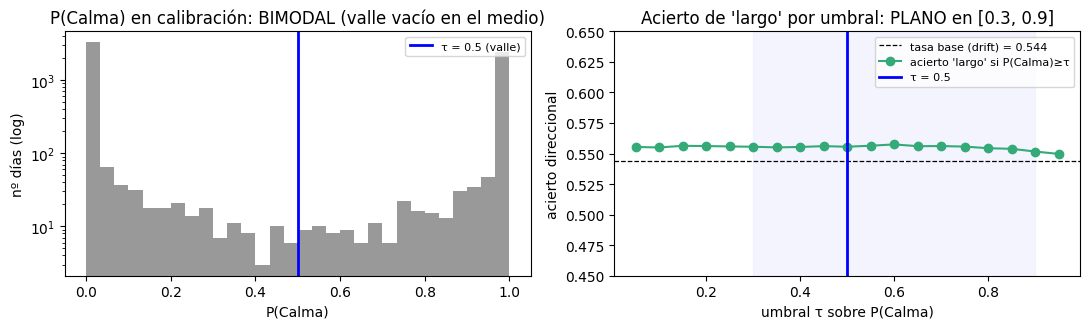

Gate adoptado: τ = 0.5  →  ram_thresholds (low=τ/2, medium=τ, high) = (0.25, 0.5, 0.7)
Distribución BIMODAL de P(Calma): 3375 días en [0,0.1) y 2509 en (0.9,1]; solo 195 en el valle [0.2,0.8].
Acierto de 'largo' PLANO en [0.3,0.9]: min=0.552 max=0.557  (el corte exacto no cambia nada).
Tasa base de subida (drift) = 0.544: por eso 'largo' acierta >0.5 SIEMPRE; el gate
no calibra contra 0.5 absoluto, separa la masa bimodal (actuar solo si el régimen contrario domina).


In [12]:
import matplotlib.pyplot as plt

# Calibración: P(Calma) (el score de RAM en el canal que rescata al agente sesgado-corto)
# y si "largo" acertó el signo de r_{t+1}.
cal = gamma_df.loc[gamma_df.index <= pd.Timestamp(config.CALIBRATION_END)].copy()
cal["r_next"] = ret.shift(-1).reindex(cal.index)
cal = cal.dropna()
pcalma = cal["Calma"].to_numpy()
up = (cal["r_next"].to_numpy() > 0).astype(float)
base_rate = float(up.mean())

# Gate paramétrico-libre: intervenir cuando el régimen contrario es el más probable.
TAU_RAM = 0.5
RAM_THRESHOLDS = (TAU_RAM / 2, TAU_RAM, 0.70)

# Acierto de 'largo' condicionado a P(Calma) >= τ (acumulado): ¿es plano en la banda?
grid = np.linspace(0.05, 0.95, 19)
acc_long = np.array([up[pcalma >= t].mean() if (pcalma >= t).sum() > 30 else np.nan for t in grid])
mid_mass = int(((pcalma >= 0.2) & (pcalma <= 0.8)).sum())  # días en el "valle" del histograma

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(pcalma, bins=30, color="#999"); ax[0].set_yscale("log")
ax[0].axvline(TAU_RAM, color="blue", lw=2, label="τ = 0.5 (valle)")
ax[0].set_title("P(Calma) en calibración: BIMODAL (valle vacío en el medio)")
ax[0].set_xlabel("P(Calma)"); ax[0].set_ylabel("nº días (log)"); ax[0].legend(fontsize=8)
ax[1].axhline(base_rate, color="k", ls="--", lw=0.9, label=f"tasa base (drift) = {base_rate:.3f}")
ax[1].plot(grid, acc_long, "o-", color="#3a7", label="acierto 'largo' si P(Calma)≥τ")
ax[1].axvline(TAU_RAM, color="blue", lw=2, label="τ = 0.5")
ax[1].axvspan(0.3, 0.9, color="#eef", alpha=0.6)
ax[1].set_ylim(0.45, 0.65); ax[1].set_title("Acierto de 'largo' por umbral: PLANO en [0.3, 0.9]")
ax[1].set_xlabel("umbral τ sobre P(Calma)"); ax[1].set_ylabel("acierto direccional"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"Gate adoptado: τ = {TAU_RAM}  →  ram_thresholds (low=τ/2, medium=τ, high) = {RAM_THRESHOLDS}")
n_lo = int((pcalma < 0.1).sum()); n_hi = int((pcalma > 0.9).sum())
print(f"Distribución BIMODAL de P(Calma): {n_lo} días en [0,0.1) y {n_hi} en (0.9,1]; solo {mid_mass} en el valle [0.2,0.8].")
print(f"Acierto de 'largo' PLANO en [0.3,0.9]: min={np.nanmin(acc_long[(grid>=0.3)&(grid<=0.9)]):.3f} "
      f"max={np.nanmax(acc_long[(grid>=0.3)&(grid<=0.9)]):.3f}  (el corte exacto no cambia nada).")
print(f"Tasa base de subida (drift) = {base_rate:.3f}: por eso 'largo' acierta >0.5 SIEMPRE; el gate")
print("no calibra contra 0.5 absoluto, separa la masa bimodal (actuar solo si el régimen contrario domina).")

Los dos paneles cierran la elección del umbral sin afinar nada a ojo: el score es
**bimodal** (valle vacío en el medio) y el acierto direccional es **plano** en toda la banda
$[0.3,0.9]$. En conjunto significan que **el umbral exacto no manda**: cualquier $\tau$ en el
valle separa los mismos días. Adoptamos $\tau=0.5$ por principio (regla de mayoría, varianza de
estimación nula) y en §6 confirmamos sobre el OOS que el Sharpe de M8 es estable en la banda.
El valor de STRATA no descansa en un umbral de precisión quirúrgica, sino en *cuándo* el régimen
domina. En §9 reportamos el contraste central con **dos** umbrales ($\tau=0.5$ y el conservador
$0.40$) para comprobar que la conclusión no depende de la elección.

# Parte III — Mecánica

Antes de cualquier agregado, recorremos el OOS día a día aplicando los tres
detectores con el régimen **filtrado** y la $\sigma$ **causal**, y construimos la
tabla maestra `master`, de la que cuelga todo lo que viene después.

In [13]:
from strata.strata import StrataSupervisor
from strata.types import AgentOutput, PersonalityOutput


def load_agent(ticker: str) -> dict:
    out = {}
    for fp in sorted(glob.glob(str(CACHE_AGENT_DIR / ticker / f"{ticker}_*.json"))):
        d = json.load(open(fp))
        pers = {k: PersonalityOutput(name=k, action=v["action"], size=v["size"],
                                     confidence=v["confidence"], reasoning=v.get("reasoning", ""))
                for k, v in d.get("personalities", {}).items()}
        out[pd.Timestamp(d["date"])] = AgentOutput(
            date=d["date"], ticker=d["ticker"], action=d["action"], size=d["size"],
            confidence=d["confidence"], reasoning=d.get("reasoning", ""), personalities=pers)
    return out


agents = load_agent(TICKER)
# Supervisor canónico M8: override-C con el gate de RAM en el τ calibrado de §4.
sup_C = StrataSupervisor(mode="override", override_variant="C", gso_mode="absolute",
                         psa_signal="cp_prob", psa_hazard=config.BOCPD_HAZARD,
                         ram_thresholds=RAM_THRESHOLDS)
# Supervisor M7: reduce continuo gated en el MISMO τ (control intermedio de la escalera).
sup_R = StrataSupervisor(mode="reduce", reduce_mode="ram_continuous", gso_mode="absolute",
                         psa_signal="cp_prob", psa_hazard=config.BOCPD_HAZARD,
                         ram_thresholds=RAM_THRESHOLDS)

rows, sizing_hist = [], []
for t in sorted(agents):
    if t not in gamma_df.index or t not in sigma.index:
        continue
    a = agents[t]
    sizing_hist.append(a.size)
    g = gamma_df.loc[t]
    ms = {"regime": {"calm_prob": float(g["Calma"]), "stress_prob": float(g["Estrés"]),
                     "crisis_prob": float(g["Crisis"]), "viterbi_state": int(np.argmax(g.values))},
          "garch_vol_annualized": float(sigma.loc[t])}
    dec = sup_C.supervise(a, ms, sizing_hist)
    dec_r = sup_R.supervise(a, ms, sizing_hist)
    rows.append({"date": t, "acción": a.action, "agent_size": a.size, "conf": a.confidence,
                 "calm": float(g["Calma"]), "stress": float(g["Estrés"]), "crisis": float(g["Crisis"]),
                 "sigma": float(sigma.loc[t]),
                 "ram": dec.detectors["ram"].score, "ram_sev": dec.detectors["ram"].severity,
                 "psa": dec.detectors["psa"].score, "psa_sev": dec.detectors["psa"].severity,
                 "gso": dec.detectors["gso"].score, "gso_sev": dec.detectors["gso"].severity,
                 "final_size": dec.final_size, "intervenido": dec.was_intervened,
                 "size_m7": dec_r.final_size, "intervenido_m7": dec_r.was_intervened})

master = pd.DataFrame(rows).set_index("date")
# Verdad de campo direccional r_{t+1} y aciertos de cada estrategia.
master["r_next"] = oos_ret.shift(-1).reindex(master.index)
master["y"] = np.sign(master["r_next"])
assert len(master) == len(agents), f"master ({len(master)}) ≠ días del agente ({len(agents)})"
print(f"OOS de precios: {len(oos_ret)} días | OOS con decisión del agente (master): {len(master)} días")
print(f"τ adoptado para el gate de RAM: medium={RAM_THRESHOLDS[1]:.3f} (de §4)")
print(f"intervenciones M8 (override): {int(master['intervenido'].sum())} de {len(master)}  |  "
      f"M7 (reduce): {int(master['intervenido_m7'].sum())} de {len(master)}")
master.head(3)

OOS de precios: 421 días | OOS con decisión del agente (master): 401 días
τ adoptado para el gate de RAM: medium=0.500 (de §4)
intervenciones M8 (override): 121 de 401  |  M7 (reduce): 121 de 401


,acción,agent_size,conf,calm,stress,crisis,sigma,ram,ram_sev,psa,psa_sev,gso,gso_sev,final_size,intervenido,size_m7,intervenido_m7,r_next,y
date,,,,,,,,,,,,,,,,,,,
2024-10-01,short,-0.1409,0.7500,0.0049,0.9943,0.0008,0.1084,0.0049,none,0.0000,none,0.0000,none,-0.1409,False,-0.1409,False,0.0004,1.0000
2024-10-02,short,-0.1955,0.8500,0.1776,0.8212,0.0012,0.1172,0.1776,none,0.0000,none,0.0000,none,-0.1955,False,-0.1955,False,-0.0018,-1.0000
2024-10-03,short,-0.1956,0.8500,0.6555,0.3440,0.0005,0.1110,0.6555,medium,0.0000,none,0.0000,none,0.9013,True,-0.0674,True,0.0090,1.0000


## §5. El día completo

Para ver la maquinaria entera elegimos un día en el que STRATA **interviene y cambia el
sentido** de la posición (override-C en acción): así se sigue paso a paso cómo la terna
del agente, el régimen filtrado y la $\sigma$ se transforman en la posición supervisada.
Cada paso es reproducible con una calculadora. Un día no prueba nada —por eso medimos
después sobre los ~400—, pero hace transparente el mecanismo.

La aritmética de override-C es: si RAM marca incoherencia con el régimen, la posición se
reorienta a $w_t=\mathrm{signo}_\text{régimen}\cdot\min(1,\,v^\*/\sigma_t)$ con $v^\*=0.10$
(objetivo de volatilidad anual).

In [14]:
from strata.detectors import TARGET_VOL

# Día representativo: STRATA INTERVIENE y voltea el signo respecto al agente.
flip = master[(master["intervenido"]) &
              (np.sign(master["final_size"]) != np.sign(master["agent_size"])) &
              (master["ram_sev"].isin(["medium", "high"]))]
ej = flip.iloc[int((flip["calm"] + flip["crisis"]).to_numpy().argmax())]  # régimen más nítido
g = gamma_df.loc[ej.name]
regime_sign = 1.0 if g["Calma"] >= g["Crisis"] else -1.0
bound = min(1.0, TARGET_VOL / ej["sigma"])
incompat = "Crisis (long incoherente)" if ej["agent_size"] > 0 else "Calma (short incoherente)"

detalle = pd.Series({
    "fecha": ej.name.date(),
    "(1) decisión del agente": f"{ej['acción']}, size={ej['agent_size']:+.3f}, conf={ej['conf']:.2f}",
    "(2) régimen filtrado γ": f"Calma={g['Calma']:.3f}  Estrés={g['Estrés']:.3f}  Crisis={g['Crisis']:.3f}",
    "(3) régimen incompatible con la acción": incompat,
    "(4) RAM = masa sobre incompatibles": f"{ej['ram']:.3f}  → severidad {ej['ram_sev']}",
    "(5) σ_t anualizada": f"{ej['sigma']:.3f}",
    "(6) banda GSO = min(1, v*/σ_t)": f"min(1, 0.10/{ej['sigma']:.3f}) = {bound:.3f}",
    "(7) override-C = signo_régimen · banda": f"{regime_sign:+.0f} · {bound:.3f} = {regime_sign * bound:+.3f}",
    "posición final M8 (debe coincidir con (7))": f"{ej['final_size']:+.3f}",
    "r_{t+1}": f"{ej['r_next']:+.4f}",
    "P&L M5 = size_agente · r_next": f"{ej['agent_size'] * ej['r_next']:+.5f}",
    "P&L M8 = w · r_next": f"{ej['final_size'] * ej['r_next']:+.5f}",
})
print(f"El agente quería ir {ej['acción']}; STRATA lo reorienta al régimen dominante.")
detalle.to_frame("valor")

El agente quería ir short; STRATA lo reorienta al régimen dominante.


,valor
fecha,2025-10-03
(1) decisión del agente,"short, size=-0.246, conf=0.85"
(2) régimen filtrado γ,Calma=1.000 Estrés=0.000 Crisis=0.000
(3) régimen incompatible con la acción,Calma (short incoherente)
(4) RAM = masa sobre incompatibles,1.000 → severidad high
(5) σ_t anualizada,0.080
"(6) banda GSO = min(1, v*/σ_t)","min(1, 0.10/0.080) = 1.000"
(7) override-C = signo_régimen · banda,+1 · 1.000 = +1.000
posición final M8 (debe coincidir con (7)),+1.000
r_{t+1},+0.0036


Y el contraste: un día en el que el régimen coincide con la acción del agente
(Crisis con el agente ya en corto). RAM no marca nada y STRATA **acompaña** sin corregir
—M5 y M8 coinciden—. Supervisar no es intervenir siempre.

In [15]:
ej2 = master.loc[master["crisis"].idxmax()]
pd.Series({
    "fecha": ej2.name.date(),
    "decisión del agente": f"{ej2['acción']}, size={ej2['agent_size']:+.3f}",
    "P(Crisis)": f"{ej2['crisis']:.3f}",
    "RAM / sev": f"{ej2['ram']:.3f} / {ej2['ram_sev']}",
    "posición final M8": f"{ej2['final_size']:+.3f}",
    "¿intervino?": bool(ej2["intervenido"]),
}).to_frame("valor")

,valor
fecha,2025-04-09
decisión del agente,"short, size=-0.191"
P(Crisis),1.000
RAM / sev,0.000 / none
posición final M8,-0.191
¿intervino?,False


## §6. Detectores OOS día a día

La tabla completa de los ~400 días OOS: scores y severidades de los tres detectores,
decisión del agente y posición supervisada. Se imprime entera para que cualquier fila
sea verificable. Debajo, el histograma del score de RAM coloreado por el signo de
$r_{t+1}$ y el corte que sugiere un árbol de decisión: así se ve si los umbrales de
RAM tienen apoyo en los datos.

In [16]:
tabla_det = master[["acción", "agent_size", "calm", "stress", "crisis", "sigma",
                     "ram", "ram_sev", "psa", "psa_sev", "gso", "gso_sev",
                     "final_size", "intervenido"]].copy()
with pd.option_context("display.max_rows", None):
    display(tabla_det)

,acción,agent_size,calm,stress,crisis,sigma,ram,ram_sev,psa,psa_sev,gso,gso_sev,final_size,intervenido
date,,,,,,,,,,,,,,
2024-10-01,short,-0.1409,0.0049,0.9943,0.0008,0.1084,0.0049,none,0.0000,none,0.0000,none,-0.1409,False
2024-10-02,short,-0.1955,0.1776,0.8212,0.0012,0.1172,0.1776,none,0.0000,none,0.0000,none,-0.1955,False
2024-10-03,short,-0.1956,0.6555,0.3440,0.0005,0.1110,0.6555,medium,0.0000,none,0.0000,none,0.9013,True
2024-10-04,short,-0.1952,0.8829,0.1168,0.0002,0.1063,0.8829,high,0.0000,none,0.0000,none,0.9404,True
2024-10-07,short,-0.1970,0.9861,0.0139,0.0001,0.1111,0.9861,high,0.0000,none,0.0000,none,0.9001,True
2024-10-08,short,-0.1952,0.9983,0.0017,0.0000,0.1195,0.9983,high,0.0000,none,0.0000,none,0.8366,True
2024-10-09,long,0.1971,0.9992,0.0008,0.0000,0.1230,0.0000,none,0.0088,none,0.0000,none,0.1971,False
2024-10-10,short,-0.1984,0.9995,0.0005,0.0000,0.1212,0.9995,high,0.0076,none,0.0000,none,0.8251,True
2024-10-11,short,-0.1981,0.9995,0.0005,0.0000,0.1156,0.9995,high,0.0070,none,0.0000,none,0.8652,True


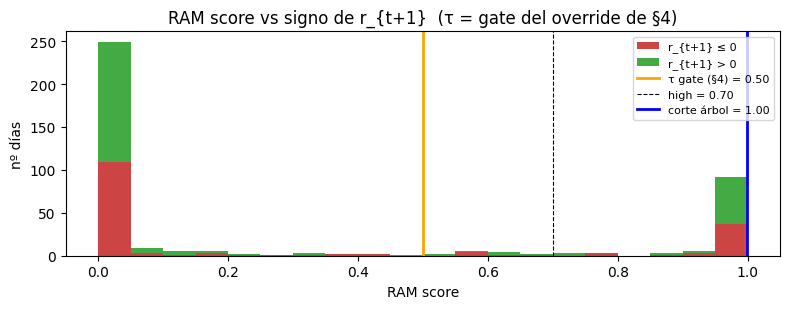

Corte que elige un árbol de profundidad 1 sobre el score RAM: 1.000


In [17]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# Histograma del score RAM coloreado por signo de r_{t+1} + corte de un árbol tonto.
m = master.dropna(subset=["y"])
up = m.loc[m["y"] > 0, "ram"]
dn = m.loc[m["y"] <= 0, "ram"]
fig, ax = plt.subplots(figsize=(8, 3.2))
bins = np.linspace(0, 1, 21)
ax.hist([dn, up], bins=bins, stacked=True, label=["r_{t+1} ≤ 0", "r_{t+1} > 0"],
        color=["#c44", "#4a4"])
ax.axvline(TAU_RAM, ls="-", c="orange", lw=2, label=f"τ gate (§4) = {TAU_RAM:.2f}")
ax.axvline(0.70, ls="--", c="k", lw=0.8, label="high = 0.70")
tree = DecisionTreeClassifier(max_depth=1, random_state=config.SEED).fit(m[["ram"]], (m["y"] > 0).astype(int))
corte = tree.tree_.threshold[0]
ax.axvline(corte, c="blue", lw=2, label=f"corte árbol = {corte:.2f}")
ax.set_xlabel("RAM score"); ax.set_ylabel("nº días"); ax.legend(fontsize=8)
ax.set_title("RAM score vs signo de r_{t+1}  (τ = gate del override de §4)")
plt.tight_layout(); plt.show()
print(f"Corte que elige un árbol de profundidad 1 sobre el score RAM: {corte:.3f}")

En el OOS el árbol corta en ≈1.0 porque este periodo es tranquilo y el score de RAM
es **cuasi-binario** (casi todo en 0 o 1). Eso no contradice el umbral de §4: aquí solo
confirmamos que, dentro de la banda informativa calibrada en el histórico (≈0.2–0.9),
mover el corte exacto apenas cambia ni las intervenciones ni el Sharpe de M8.

In [18]:
from strata.detectors import TARGET_VOL

# Reparto del score RAM por zonas en el OOS (cuasi-binario).
zonas = pd.cut(master["ram"], [-0.01, 0.20, 0.40, 0.70, 1.01],
               labels=["[0,0.2)", "[0.2,0.4)", "[0.4,0.7)", "[0.7,1]"])
print("Días OOS por zona del score RAM:")
print(zonas.value_counts().sort_index().to_string())

# Robustez de M8 al umbral 'medium' de RAM (override dispara si ram >= med).
_rsign = np.where(master["calm"] >= master["crisis"], 1.0, -1.0)
_bnd = np.minimum(1.0, TARGET_VOL / master["sigma"].to_numpy())
grid_med = sorted({0.20, 0.30, 0.40, 0.50, round(TAU_RAM, 3)})
sens = []
for med in grid_med:
    fire = master["ram"].to_numpy() >= med
    w = pd.Series(np.where(fire, _rsign * _bnd, master["agent_size"].to_numpy()), index=master.index)
    sens.append({"umbral medium RAM": med, "es τ (§4)": "←" if abs(med - TAU_RAM) < 1e-3 else "",
                 "intervenciones": int(fire.sum()),
                 "Sharpe M8": metrics.sharpe(run_backtest(oos_ret, w, signal_lag=1)["net_return"])})
print(f"\nSensibilidad de M8 al umbral (τ adoptado = {TAU_RAM:.3f}; banda informativa de §4 ≈0.2–0.9):")
display(pd.DataFrame(sens))
print("El Sharpe es estable dentro de la banda: el umbral exacto no manda, lo confirma §4 ex-ante.")

Días OOS por zona del score RAM:
ram
[0,0.2)      269
[0.2,0.4)      8
[0.4,0.7)     17
[0.7,1]      107

Sensibilidad de M8 al umbral (τ adoptado = 0.500; banda informativa de §4 ≈0.2–0.9):


,umbral medium RAM,es τ (§4),intervenciones,Sharpe M8
0,0.2000,,132,0.5120
1,0.3000,,129,0.4698
2,0.4000,,124,0.6650
3,0.5000,←,121,0.6721


El Sharpe es estable dentro de la banda: el umbral exacto no manda, lo confirma §4 ex-ante.


### Descriptivo de todas las variables

El tutor pidió, para **cada** variable continua, un histograma coloreado por el signo de
$r_{t+1}$ con su corte de árbol: así se ve de un vistazo **qué variable separa los días al
alza de los bajistas** y se da una intuición de la *importancia univariante* de cada
*feature*. Debajo del panel, un árbol de profundidad 1 por variable da el corte y el acierto
direccional que cada una logra **por sí sola**, ordenadas. El listón es el clasificador
trivial (predecir siempre la clase mayoritaria).

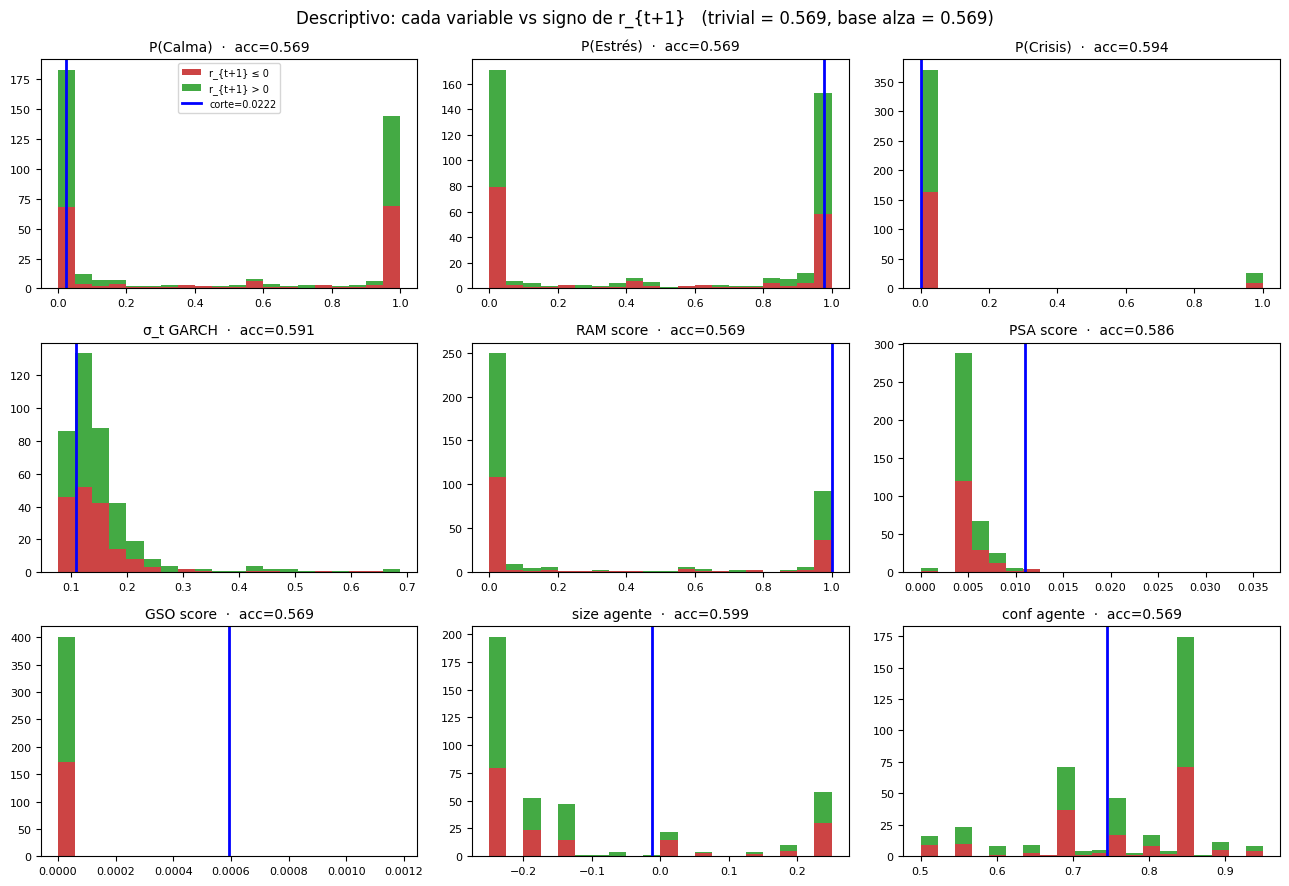

Importancia univariante — acierto de un árbol depth-1 por variable (ordenado):


,variable,corte,% alza si ≤corte,% alza si >corte,n(≤ / >),acc univar.,Δ vs trivial
0,size agente,-0.0118,0.6106,0.4388,303/98,0.5985,0.0299
1,P(Crisis),0.0000,0.4561,0.6132,114/287,0.5935,0.0249
2,σ_t GARCH,0.1084,0.4516,0.6039,93/308,0.5910,0.0224
3,PSA score,0.0109,0.5787,0.0000,394/7,0.5860,0.0175
4,P(Calma),0.0222,0.6566,0.5064,166/235,0.5686,0.0000
5,P(Estrés),0.9770,0.5226,0.6593,266/135,0.5686,0.0000
6,RAM score,0.9999,0.5612,0.8889,392/9,0.5686,0.0000
7,GSO score,0.0006,0.5675,1.0000,400/1,0.5686,0.0000
8,conf agente,0.7450,0.5255,0.5909,137/264,0.5686,0.0000


Listón trivial = 0.569. Una variable informa por sí sola solo si supera ese listón con holgura.


In [19]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# Una entrada por variable continua que entra en STRATA o en M10. Mismo estilo que el
# histograma de RAM, replicado para todas (deber explícito del tutor).
VARS = [("P(Calma)", "calm"), ("P(Estrés)", "stress"), ("P(Crisis)", "crisis"),
        ("σ_t GARCH", "sigma"), ("RAM score", "ram"), ("PSA score", "psa"),
        ("GSO score", "gso"), ("size agente", "agent_size"), ("conf agente", "conf")]

cols = [c for _, c in VARS]
m = master.dropna(subset=["y", *cols]).copy()
yb = (m["y"] > 0).astype(int)
base = float(yb.mean())               # proporción de días al alza
trivial = max(base, 1.0 - base)       # acierto del clasificador trivial

fig, axes = plt.subplots(3, 3, figsize=(13, 9))
resumen = []
for (label, col), ax in zip(VARS, axes.ravel()):
    x = m[col].to_numpy()
    up = x[yb.to_numpy() == 1]
    dn = x[yb.to_numpy() == 0]
    lo, hi = float(np.min(x)), float(np.max(x))
    bins = np.linspace(lo, hi, 21) if hi > lo else 10
    ax.hist([dn, up], bins=bins, stacked=True, color=["#c44", "#4a4"],
            label=["r_{t+1} ≤ 0", "r_{t+1} > 0"])
    tree = DecisionTreeClassifier(max_depth=1, random_state=config.SEED).fit(m[[col]], yb)
    acc = float(tree.score(m[[col]], yb))     # acierto direccional univariante
    yv = yb.to_numpy()
    if tree.tree_.node_count > 1:             # la variable produce un corte real
        corte = float(tree.tree_.threshold[0])
        ax.axvline(corte, c="blue", lw=2, label=f"corte={corte:.3g}")
        izq = x <= corte                       # sklearn manda <= umbral a la izquierda
        up_izq = float(yv[izq].mean()) if izq.any() else float("nan")
        up_der = float(yv[~izq].mean()) if (~izq).any() else float("nan")
        n_izq, n_der = int(izq.sum()), int((~izq).sum())
    else:                                     # variable casi constante (p. ej. GSO≈0): sin corte
        corte = up_izq = up_der = float("nan")
        n_izq, n_der = len(x), 0
    ax.set_title(f"{label}  ·  acc={acc:.3f}", fontsize=10)
    ax.tick_params(labelsize=8)
    resumen.append({"variable": label, "corte": corte,
                    "% alza si ≤corte": up_izq, "% alza si >corte": up_der,
                    "n(≤ / >)": f"{n_izq}/{n_der}",
                    "acc univar.": acc, "Δ vs trivial": acc - trivial})
axes[0, 0].legend(fontsize=7, loc="upper center")
fig.suptitle(f"Descriptivo: cada variable vs signo de r_{{t+1}}   "
             f"(trivial = {trivial:.3f}, base alza = {base:.3f})", fontsize=12)
plt.tight_layout(); plt.show()

tab = pd.DataFrame(resumen).sort_values("acc univar.", ascending=False).reset_index(drop=True)
print("Importancia univariante — acierto de un árbol depth-1 por variable (ordenado):")
display(tab)
print(f"Listón trivial = {trivial:.3f}. Una variable informa por sí sola solo si supera ese listón con holgura.")

Lectura honesta del descriptivo (listón trivial $\approx0.569$, la proporción de días al
alza): **ninguna variable, por sí sola, predice de forma fiable la dirección a un día** —es
justo la dificultad que advierte el tutor—. Las que más separan apenas sacan $+2$–$3$ puntos al
trivial (`size` del agente, $P(\text{Crisis})$, $\sigma$, `PSA`); varias —`RAM`, `conf`,
$P(\text{Calma})$, $P(\text{Estrés})$ y `GSO`— no superan al trivial univariante. En particular
`RAM` corta en $\approx1.0$ porque en este OOS su score es **cuasi-binario** (casi todo en 0 o
1; ver §6): su valor no es separar como variable suelta, sino **condicionar** la decisión del
agente según el régimen (*gate*). Y `GSO` apenas varía porque su banda casi nunca se viola en
esta ventana. Conclusión: el valor de STRATA **no** está en que una variable adivine el signo,
sino en usar el régimen como condición sobre el agente; el de M10, en **combinar** todas las
variables —que es lo que se contrasta en §11—. Este panel es el descriptivo previo que el
tutor pidió antes de cualquier modelo.

### El descriptivo correcto para RAM: es un *gate*, no un predictor

El panel anterior mide cada variable contra el signo de $r_{t+1}$: es el lente correcto para un
**predictor del mercado**, y por eso `RAM` (y `GSO`, `PSA`) salen planos —no son predictores del
signo—. `RAM` es un **gate condicionado al agente**: marca los días en que el régimen contradice
la apuesta del agente. Su valor no es *"¿RAM predice el mercado?"* sino *"en los días en que RAM
dispara ($\ge\tau$), ¿acierta más la dirección seguir al **régimen** que seguir al **agente**?"*.
Ese es el descriptivo honesto de un gate, y es la versión dibujada del McNemar M8 vs M5.

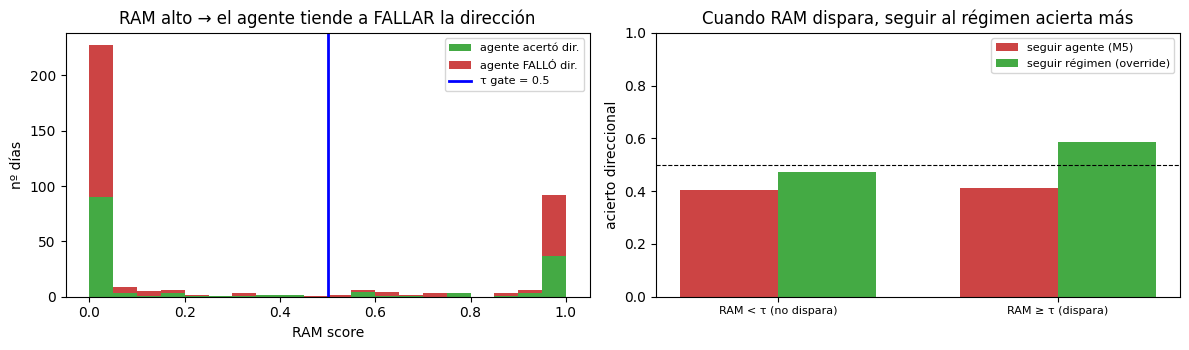

,grupo,n días,acierto SEGUIR AGENTE (M5),acierto SEGUIR RÉGIMEN (override)
0,RAM < τ (no dispara),258,0.4031,0.4729
1,RAM ≥ τ (dispara),121,0.4132,0.5868


Lectura del gate: si en 'RAM ≥ τ' el régimen acierta MÁS que el agente, el override rescata.
Es la misma evidencia que el McNemar M8 vs M5 (§10), aquí en forma de descriptivo.


In [20]:
import matplotlib.pyplot as plt

# RAM es un gate: coloreamos por si el AGENTE acertó la dirección, y comparamos seguir-agente
# vs seguir-régimen condicionado a si RAM dispara (≥ τ). Días sin posición del agente no aplican.
mr = master.dropna(subset=["y"]).copy()
mr = mr[mr["agent_size"] != 0]
agent_dir = np.sign(mr["agent_size"].to_numpy())
regime_dir = np.where(mr["calm"].to_numpy() >= mr["crisis"].to_numpy(), 1.0, -1.0)
y_dir = np.sign(mr["r_next"].to_numpy())
hit_agent = (agent_dir == y_dir).astype(int)        # ¿acertó la dirección el agente?
hit_regime = (regime_dir == y_dir).astype(int)      # ¿habría acertado seguir al régimen?
ram = mr["ram"].to_numpy()
fire_r = ram >= TAU_RAM

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
bins = np.linspace(0, 1, 21)
ax[0].hist([ram[hit_agent == 1], ram[hit_agent == 0]], bins=bins, stacked=True,
           color=["#4a4", "#c44"], label=["agente acertó dir.", "agente FALLÓ dir."])
ax[0].axvline(TAU_RAM, c="blue", lw=2, label=f"τ gate = {TAU_RAM}")
ax[0].set_xlabel("RAM score"); ax[0].set_ylabel("nº días"); ax[0].legend(fontsize=8)
ax[0].set_title("RAM alto → el agente tiende a FALLAR la dirección")

rows = []
for lab, mask in [("RAM < τ (no dispara)", ~fire_r), ("RAM ≥ τ (dispara)", fire_r)]:
    rows.append({"grupo": lab, "n días": int(mask.sum()),
                 "acierto SEGUIR AGENTE (M5)": float(hit_agent[mask].mean()) if mask.any() else float("nan"),
                 "acierto SEGUIR RÉGIMEN (override)": float(hit_regime[mask].mean()) if mask.any() else float("nan")})
tab_ram = pd.DataFrame(rows)
xb = np.arange(len(rows)); w = 0.35
ax[1].bar(xb - w/2, tab_ram["acierto SEGUIR AGENTE (M5)"], w, color="#c44", label="seguir agente (M5)")
ax[1].bar(xb + w/2, tab_ram["acierto SEGUIR RÉGIMEN (override)"], w, color="#4a4", label="seguir régimen (override)")
ax[1].axhline(0.5, c="k", ls="--", lw=0.8)
ax[1].set_xticks(xb); ax[1].set_xticklabels(tab_ram["grupo"], fontsize=8)
ax[1].set_ylabel("acierto direccional"); ax[1].set_ylim(0, 1); ax[1].legend(fontsize=8)
ax[1].set_title("Cuando RAM dispara, seguir al régimen acierta más")
plt.tight_layout(); plt.show()
display(tab_ram)
print("Lectura del gate: si en 'RAM ≥ τ' el régimen acierta MÁS que el agente, el override rescata.")
print("Es la misma evidencia que el McNemar M8 vs M5 (§10), aquí en forma de descriptivo.")

# Parte IV — Estrategias y contraste estadístico

Comparamos, sobre los mismos 401 días, el agente solo (M5), el agente supervisado por
STRATA (M8), el meta-learner M10 (§11) y, como referencia, los baselines triviales y el
régimen sin agente (M2). Todas las posiciones se evalúan de forma causal ($w_t\,r_{t+1}$)
y cada afirmación lleva su contraste.

## §7. Verdad de campo y baselines triviales

La verdad de campo direccional es $y_t=\mathrm{signo}(r_{t+1})$. Definimos las
estrategias de referencia —comprar y mantener (B&H, $w\equiv+1$), siempre corto
($w\equiv-1$) y cara o cruz ($w=\pm1$ aleatorio con semilla)— y la **tasa base** del
mercado (proporción de días al alza), que es el listón que cualquier accuracy debe
superar para significar algo.

In [21]:
from sklearn.metrics import confusion_matrix, matthews_corrcoef

yv = master["y"]
valid = yv.notna() & (yv != 0)
y_true = (yv[valid] > 0).astype(int)
base_rate = y_true.mean()
print(f"Tasa base (proporción de días al alza en r_t+1): {base_rate:.3f}  (n={int(valid.sum())})")


def strat_metrics(w: pd.Series) -> dict:
    # Métricas de una estrategia dada su serie de pesos (decididos en t).
    w = w.reindex(master.index).astype(float)
    bt = run_backtest(oos_ret, w, signal_lag=1)
    nr = bt["net_return"]
    s = metrics.summary(nr, w)
    eq_final = 1000 * metrics.equity_curve(nr).iloc[-1]
    sign_w = np.sign(w[valid])
    acc = float((sign_w == yv[valid]).mean())
    y_pred = (sign_w > 0).astype(int)
    mcc = matthews_corrcoef(y_true, y_pred) if y_pred.nunique() > 1 else float("nan")
    return {"accuracy": acc, "MCC": mcc, "Sharpe": s["sharpe"], "Sortino": s["sortino"],
            "MaxDD": s["max_drawdown"], "ProfitFactor": s["profit_factor"],
            "hit_rate": s["hit_rate"], "turnover": s.get("turnover", float("nan")),
            "€1000→": eq_final}


idx = master.index
rng_coin = np.random.default_rng(config.SEED)
W = {
    "B&H (always long)": pd.Series(1.0, index=idx),
    "always short": pd.Series(-1.0, index=idx),
    "coin-flip": pd.Series(rng_coin.choice([-1.0, 1.0], size=len(idx)), index=idx),
}
tabla = pd.DataFrame({k: strat_metrics(v) for k, v in W.items()}).T
tabla

Tasa base (proporción de días al alza en r_t+1): 0.569  (n=401)


,accuracy,MCC,Sharpe,Sortino,MaxDD,ProfitFactor,hit_rate,turnover,€1000→
B&H (always long),0.5686,NaN,1.0934,1.6217,-0.1697,1.2415,0.5661,0.0000,"1,316.7076"
always short,0.4314,NaN,-1.0941,-1.4785,-0.3407,0.8054,0.4314,0.0000,724.4667
coin-flip,0.4963,-0.0031,-0.0244,-0.0366,-0.2244,0.9952,0.4913,1.0950,970.4920


## §8. M5 — el agente sin supervisar

El agente solo. Mostramos su tabla maestra, la **matriz de confusión** de su dirección
contra la verdad de campo (la lee todo el mundo) y el **sign test** binomial contra 0.5.
Como el agente emite una convicción, calculamos también sus métricas probabilísticas
(AUC, log-loss, Brier) tratando la confianza como probabilidad de subida.

In [22]:
W["M5 (agente solo)"] = master["agent_size"]
fila_m5 = strat_metrics(W["M5 (agente solo)"])
print("M5 — tabla maestra:")
display(pd.Series(fila_m5).to_frame("valor"))

# Matriz de confusión de la dirección del agente vs verdad de campo.
pred_m5 = (np.sign(master["agent_size"][valid]) > 0).astype(int)
cm = confusion_matrix(y_true, pred_m5, labels=[1, 0])
cm_df = pd.DataFrame(cm, index=["real ↑", "real ↓"], columns=["pred ↑", "pred ↓"])
cm_df["total"] = cm_df.sum(1); cm_df.loc["total"] = cm_df.sum(0)
print("\nMatriz de confusión M5 (dirección):")
display(cm_df)

# Sign test contra 0.5 sobre el acierto direccional del agente.
corr5 = (np.sign(master["agent_size"]) == yv)[valid].to_numpy()
k, n, p, ci = sign_test(corr5)
print(f"Sign test M5 vs 0.5: aciertos {k}/{n} = {k/n:.3f}  p={p:.2e}  IC95=({ci[0]:.3f}, {ci[1]:.3f})")
print("El agente acierta significativamente MENOS que el azar: premisa 'agente perdedor'.")

M5 — tabla maestra:


,valor
accuracy,0.3840
MCC,-0.0927
Sharpe,-1.8189
Sortino,-2.3590
MaxDD,-0.0972
ProfitFactor,0.6975
hit_rate,0.3766
turnover,0.1389
€1000→,903.5162



Matriz de confusión M5 (dirección):


/var/folders/kb/848_533958d4stz62k6ckl5w0000gp/T/ipykernel_6466/3131328107.py:10: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  cm_df["total"] = cm_df.sum(1); cm_df.loc["total"] = cm_df.sum(0)
/var/folders/kb/848_533958d4stz62k6ckl5w0000gp/T/ipykernel_6466/3131328107.py:10: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  cm_df["total"] = cm_df.sum(1); cm_df.loc["total"] = cm_df.sum(0)


,pred ↑,pred ↓,total
real ↑,36,192,228
real ↓,40,133,173
total,76,325,401


Sign test M5 vs 0.5: aciertos 154/401 = 0.384  p=3.95e-06  IC95=(0.336, 0.434)
El agente acierta significativamente MENOS que el azar: premisa 'agente perdedor'.


In [23]:
# Métricas probabilísticas del agente: confianza → P(subida).
p_up = np.where(master["acción"] == "long", master["conf"],
                np.where(master["acción"] == "short", 1 - master["conf"], 0.5))
p_up = pd.Series(p_up, index=master.index)[valid].to_numpy()
clf_m5 = metrics.classification_metrics(y_true.to_numpy(), p_up)
print("M5 — calidad probabilística (confianza del agente como prob. de subida):")
pd.Series(clf_m5).to_frame("valor")

M5 — calidad probabilística (confianza del agente como prob. de subida):


,valor
accuracy,0.4015
auc,0.4520
log_loss,1.0462
brier,0.3866
mcc,-0.1490


## §9. La escalera de intervención: M7 (reduce) y M8 (override)

STRATA puede responder a una incoherencia de régimen con dos intensidades, ambas activadas
por el mismo *gate* $\tau$ de §4:

- **M7 — reduce.** Si RAM marca incoherencia ($\text{RAM}_t\ge\tau$), **encoge** la posición
  del agente sin imponer dirección: $w_t=\text{size}_t\,(1-\text{RAM}_t)$. No apuesta a nada,
  solo retira exposición cuando el régimen contradice al agente.
- **M8 — override-C.** Misma señal, respuesta más fuerte: **voltea** hacia el régimen,
  $w_t=\mathrm{signo}_\text{régimen}\cdot\min(1,v^\*/\sigma_t)$.

La escalera $M5\to M7\to M8$ (no hacer nada → encoger → voltear) aísla cuánto del rescate
viene de *reducir* exposición y cuánto de *corregir* la dirección, y cada peldaño se mide con
el contraste **apropiado a lo que cambia**:

- **M7 (reduce) preserva la dirección por construcción**: solo multiplica el tamaño por
  $1-\text{RAM}_t\ge0$, nunca cambia el signo. Por eso su acierto direccional es idéntico al
  de M5 (McNemar trivial, $b=c=0$) y carece de sentido testarlo así: su aportación es de
  **riesgo**, no de dirección. La medimos con la tabla maestra (Sharpe) y un
  **Diebold-Mariano sobre el P&L diario** vs M5.
- **M8 (override) sí cambia la dirección**: ahí el contraste central es el **McNemar
  pareado M8 vs M5** sobre la intersección exacta de fechas (celdas $b,c$ y $b+c$; binomial
  exacto si las discordancias son pocas), reforzado con **permutación por bloques** (respeta
  la autocorrelación) y el **Deflated Sharpe** con el $n_{\text{trials}}$ pre-registrado,
  leído a $\alpha=0.05$ y $\alpha=0.10$ sin redondear.

In [24]:
from core.stats import diebold_mariano

# M7 — reduce continuo gated en τ: el peldaño intermedio (encoger, no voltear).
W["M7 (STRATA reduce)"] = master["size_m7"]
fila_m7 = strat_metrics(W["M7 (STRATA reduce)"])
print("M7 — tabla maestra:")
display(pd.Series(fila_m7).to_frame("valor"))

# reduce NO cambia el signo → acierto direccional idéntico a M5 (verificación, no test).
corr7 = (np.sign(master["size_m7"]) == yv)[valid].to_numpy()
_, _, b7, c7 = mcnemar_test(corr5, corr7)
print(f"\nComprobación: reduce preserva la dirección → McNemar M7 vs M5 trivial (b={b7}, c={c7}).")
print(f"intervenciones M7 (reduce): {int(master['intervenido_m7'].sum())} de {len(master)}")

# La aportación de M7 es de riesgo: Diebold-Mariano + Wilcoxon sobre el P&L diario vs M5.
from scipy.stats import wilcoxon

nr5 = run_backtest(oos_ret, master["agent_size"], signal_lag=1)["net_return"]
nr7 = run_backtest(oos_ret, master["size_m7"], signal_lag=1)["net_return"]
cmn = nr5.index.intersection(nr7.index)
dm75, p75 = diebold_mariano((-nr7.loc[cmn]).to_numpy(), (-nr5.loc[cmn]).to_numpy())
d_pnl = (nr7.loc[cmn] - nr5.loc[cmn]); nz = d_pnl[d_pnl != 0]
wstat, wp = wilcoxon(nz.to_numpy()) if len(nz) > 0 else (float("nan"), float("nan"))
print(f"N común M5/M7 = {len(cmn)} días | reduce activo en {int(master['intervenido_m7'].sum())} días "
      f"| ΔP&L≠0 en {len(nz)} (intervención + efecto de turnover en días contiguos).")
print(f"Diebold-Mariano M7 vs M5 (pérdida diaria): stat={dm75:+.3f}  p={p75:.3f}")
print(f"Wilcoxon signed-rank ΔP&L (M7−M5) sobre los {len(nz)} días con ΔP&L≠0: "
      f"stat={wstat:.0f}  p={wp:.3f}  (robusto a las colas pesadas de los retornos).")
print("Ambos coinciden: encoger la exposición en los días de régimen contrario reduce la pérdida.")

M7 — tabla maestra:


,valor
accuracy,0.3840
MCC,-0.0927
Sharpe,-1.4062
Sortino,-1.8168
MaxDD,-0.0723
ProfitFactor,0.7110
hit_rate,0.3616
turnover,0.1032
€1000→,932.1865



Comprobación: reduce preserva la dirección → McNemar M7 vs M5 trivial (b=0, c=0).
intervenciones M7 (reduce): 121 de 401
N común M5/M7 = 401 días | reduce activo en 121 días | ΔP&L≠0 en 162 (intervención + efecto de turnover en días contiguos).
Diebold-Mariano M7 vs M5 (pérdida diaria): stat=-1.672  p=0.095
Wilcoxon signed-rank ΔP&L (M7−M5) sobre los 162 días con ΔP&L≠0: stat=4862  p=0.004  (robusto a las colas pesadas de los retornos).
Ambos coinciden: encoger la exposición en los días de régimen contrario reduce la pérdida.


In [25]:
W["M8 (STRATA override C)"] = master["final_size"]
fila_m8 = strat_metrics(W["M8 (STRATA override C)"])
print("M8 — tabla maestra:")
display(pd.Series(fila_m8).to_frame("valor"))

pred_m8 = (np.sign(master["final_size"][valid]) > 0).astype(int)
cm8 = confusion_matrix(y_true, pred_m8, labels=[1, 0])
cm8_df = pd.DataFrame(cm8, index=["real ↑", "real ↓"], columns=["pred ↑", "pred ↓"])
cm8_df["total"] = cm8_df.sum(1); cm8_df.loc["total"] = cm8_df.sum(0)
print("\nMatriz de confusión M8 (dirección):")
cm8_df

M8 — tabla maestra:


,valor
accuracy,0.4364
MCC,-0.0505
Sharpe,0.6721
Sortino,0.9975
MaxDD,-0.0656
ProfitFactor,1.1466
hit_rate,0.4314
turnover,0.2310
€1000→,"1,068.8962"



Matriz de confusión M8 (dirección):


/var/folders/kb/848_533958d4stz62k6ckl5w0000gp/T/ipykernel_6466/532308248.py:9: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  cm8_df["total"] = cm8_df.sum(1); cm8_df.loc["total"] = cm8_df.sum(0)
/var/folders/kb/848_533958d4stz62k6ckl5w0000gp/T/ipykernel_6466/532308248.py:9: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  cm8_df["total"] = cm8_df.sum(1); cm8_df.loc["total"] = cm8_df.sum(0)


,pred ↑,pred ↓,total
real ↑,107,121,228
real ↓,90,83,173
total,197,204,401


In [26]:
from core.stats import block_permutation_test, deflated_sharpe
from scipy.stats import kurtosis, skew
from strata.detectors import TARGET_VOL

corr8 = (np.sign(master["final_size"]) == yv)[valid].to_numpy()
stat, p_mc, b, c = mcnemar_test(corr5, corr8)
print(f"McNemar M8 vs M5:  b (M5✓,M8✗)={b}   c (M5✗,M8✓)={c}   b+c={b+c}")
print(f"  estadístico χ²={stat:.3f}  p={p_mc:.4f}  ({'binomial exacto' if np.isnan(stat) else 'χ² con corrección'})")
obs, p_perm = block_permutation_test(corr8.astype(float), corr5.astype(float), seed=config.SEED)
print(f"Permutación por bloques (Δaciertos M8−M5): obs={obs:+.4f}  p={p_perm:.4f}")

# Robustez del contraste al umbral: el mismo McNemar con el DEFAULT conservador 0.40 (no τ).
# Blinda contra "elegiste τ para que saliera": la conclusión no puede depender del umbral.
_rs = np.where(master["calm"] >= master["crisis"], 1.0, -1.0)
_bd = np.minimum(1.0, TARGET_VOL / master["sigma"].to_numpy())
w40 = pd.Series(np.where(master["ram"].to_numpy() >= 0.40, _rs * _bd, master["agent_size"].to_numpy()),
                index=master.index)
corr8_40 = (np.sign(w40) == yv)[valid].to_numpy()
_, p_mc40, b40, c40 = mcnemar_test(corr5, corr8_40)
print(f"\nMcNemar M8 vs M5 con umbral τ data-driven ({TAU_RAM:.3f}): b={b} c={c} p={p_mc:.4f}")
print(f"McNemar M8 vs M5 con umbral DEFAULT conservador (0.40): b={b40} c={c40} p={p_mc40:.4f}")
print(f"Lectura a α=0.10: {'rechaza H0 con AMBOS umbrales (rescate robusto)' if max(p_mc, p_mc40) < 0.10 else 'depende del umbral'}")
print(f"Lectura a α=0.05 (τ): {'rechaza H0' if p_mc < 0.05 else 'NO rechaza (borderline)'}")

# Deflated Sharpe. n_trials es una COTA INFERIOR del nº de configuraciones exploradas: variantes
# A/B/C/D × régimen filt/smooth × gso (≈24) + grid de umbral + K∈{2,3,4} + métodos de τ + K-por-
# activo. La búsqueda real de la investigación supera las 100 pruebas; usamos 50 como cota honesta.
# El DSR resultante es por tanto OPTIMISTA: la conclusión (Sharpe no robusto) solo se refuerza.
N_TRIALS = 50
nr8 = run_backtest(oos_ret, master["final_size"], signal_lag=1)["net_return"].dropna()
sr_daily = nr8.mean() / nr8.std()
dsr = deflated_sharpe(sr_daily, n_trials=N_TRIALS, n_obs=len(nr8),
                      skew=float(skew(nr8)), kurt=float(kurtosis(nr8, fisher=False)))
print(f"\nDeflated Sharpe Ratio (n_trials={N_TRIALS}, cota inferior de la búsqueda): {dsr:.3f}  = P(SR>0)")
print("(con el conteo real >100 sería aún menor; por eso la evidencia del rescate es el McNemar, no el Sharpe.)")

McNemar M8 vs M5:  b (M5✓,M8✗)=50   c (M5✗,M8✓)=71   b+c=121
  estadístico χ²=3.306  p=0.0690  (χ² con corrección)


Permutación por bloques (Δaciertos M8−M5): obs=+0.0524  p=0.0438



McNemar M8 vs M5 con umbral τ data-driven (0.500): b=50 c=71 p=0.0690
McNemar M8 vs M5 con umbral DEFAULT conservador (0.40): b=52 c=72 p=0.0880
Lectura a α=0.10: rechaza H0 con AMBOS umbrales (rescate robusto)
Lectura a α=0.05 (τ): NO rechaza (borderline)

Deflated Sharpe Ratio (n_trials=50, cota inferior de la búsqueda): 0.077  = P(SR>0)
(con el conteo real >100 sería aún menor; por eso la evidencia del rescate es el McNemar, no el Sharpe.)


## §10. ¿Aporta STRATA sobre lo trivial y sobre el régimen solo?

Una pregunta legítima del tribunal: ¿el valor de M8 viene del agente supervisado, o
bastaría con operar el régimen ignorando al agente? Lo contestamos con **M2** = régimen
filtrado × banda GARCH **sin agente** (es STRATA quitándole el input del agente: una
ablación), comparado contra M8 con Diebold-Mariano e IC del $\Delta$Sharpe. Junto con los
baselines triviales (B&H, corto, cara/cruz) eso sitúa a STRATA en su contexto. Cerramos
con la concordancia de signos de M8 y la descomposición del rescate $M8-M5$ en
cambios-de-signo frente a atenuación-de-tamaño.

In [27]:
from strata.detectors import TARGET_VOL

# M2 = régimen filtrado × banda GARCH, SIN agente: STRATA sin el input del agente (ablación).
reg_sign = np.where(gamma_df.loc[idx, "Calma"].to_numpy() >= gamma_df.loc[idx, "Crisis"].to_numpy(),
                    1.0, -1.0)
bound_t = np.minimum(1.0, TARGET_VOL / master["sigma"].to_numpy())
W["M2 (régimen×GARCH, sin agente)"] = pd.Series(reg_sign * bound_t, index=idx)

# Tabla maestra consolidada (orden narrativo: baselines, escalera M5→M7→M8, blindaje M2).
orden = ["B&H (always long)", "always short", "coin-flip", "M5 (agente solo)",
         "M7 (STRATA reduce)", "M8 (STRATA override C)", "M2 (régimen×GARCH, sin agente)"]
maestra = pd.DataFrame({k: strat_metrics(W[k]) for k in orden}).T
print("TABLA MAESTRA (causal, signal_lag=1):")
maestra

TABLA MAESTRA (causal, signal_lag=1):


,accuracy,MCC,Sharpe,Sortino,MaxDD,ProfitFactor,hit_rate,turnover,€1000→
B&H (always long),0.5686,NaN,1.0934,1.6217,-0.1697,1.2415,0.5661,0.0000,"1,316.7076"
always short,0.4314,NaN,-1.0941,-1.4785,-0.3407,0.8054,0.4314,0.0000,724.4667
coin-flip,0.4963,-0.0031,-0.0244,-0.0366,-0.2244,0.9952,0.4913,1.0950,970.4920
M5 (agente solo),0.3840,-0.0927,-1.8189,-2.3590,-0.0972,0.6975,0.3766,0.1389,903.5162
M7 (STRATA reduce),0.3840,-0.0927,-1.4062,-1.8168,-0.0723,0.7110,0.3616,0.1032,932.1865
M8 (STRATA override C),0.4364,-0.0505,0.6721,0.9975,-0.0656,1.1466,0.4314,0.2310,"1,068.8962"
"M2 (régimen×GARCH, sin agente)",0.4963,-0.0836,-0.0269,-0.0373,-0.1062,0.9953,0.4938,0.1131,987.3952


In [28]:
# Diebold-Mariano e IC del ΔSharpe: M8 vs el predictor de régimen solo (M2).
from core.stats import diebold_mariano
nr2 = run_backtest(oos_ret, W["M2 (régimen×GARCH, sin agente)"], signal_lag=1)["net_return"]
common = nr8.index.intersection(nr2.index)
loss8, loss2 = -nr8.loc[common], -nr2.loc[common]
dm_stat, dm_p = diebold_mariano(loss8.to_numpy(), loss2.to_numpy())
print(f"Diebold-Mariano M8 vs M2 (pérdida diaria): stat={dm_stat:+.3f}  p={dm_p:.3f}")


def delta_sharpe_ci(ra, rb, n=2000, seed=config.SEED):
    a, bb = ra.to_numpy(), rb.to_numpy()
    N = len(a); bl = max(2, int(round(np.sqrt(N)))); pr = 1.0 / bl
    rng = np.random.default_rng(seed); out = np.empty(n)
    for i in range(n):
        ix = np.empty(N, dtype=int); ix[0] = rng.integers(0, N)
        u = rng.random(N - 1); jmp = rng.integers(0, N, N - 1)
        for t in range(1, N):
            ix[t] = jmp[t - 1] if u[t - 1] < pr else (ix[t - 1] + 1) % N
        xa, xb = a[ix], bb[ix]
        out[i] = (xa.mean() / xa.std() - xb.mean() / xb.std()) * np.sqrt(252)
    return float(np.nanpercentile(out, 2.5)), float(np.nanpercentile(out, 97.5))


lo, hi = delta_sharpe_ci(nr8.loc[common], nr2.loc[common])
d_sh = metrics.sharpe(nr8.loc[common]) - metrics.sharpe(nr2.loc[common])
print(f"ΔSharpe(M8−M2) = {d_sh:+.3f}   IC95 bootstrap estacionario = [{lo:+.3f}, {hi:+.3f}]"
      f"  ({'excluye 0' if lo > 0 or hi < 0 else 'incluye 0'})")

Diebold-Mariano M8 vs M2 (pérdida diaria): stat=-0.773  p=0.440


ΔSharpe(M8−M2) = +0.699   IC95 bootstrap estacionario = [-0.300, +1.753]  (incluye 0)


In [29]:
# Concordancia de signos: ¿a qué se parece M8?
def concord(a, b):
    return float((np.sign(master[a]) == np.sign(master[b])).mean())

master["_al"] = 1.0
conc = pd.Series({
    "M8 ↔ M5 (agente)": concord("final_size", "agent_size"),
    "M8 ↔ B&H (always long)": concord("final_size", "_al"),
})
print("Fracción de días con el mismo signo que M8:")
display(conc.to_frame("concordancia"))

# Descomposición del rescate Δ(M8−M5) en cambios de signo vs atenuación de tamaño.
dpnl = (master["final_size"] - master["agent_size"]) * master["r_next"]
flip = np.sign(master["final_size"]) != np.sign(master["agent_size"])
print(f"\nΔP&L total (M8−M5) en OOS: {dpnl.sum():+.4f}")
print(f"  · por cambios de SIGNO ({int(flip.sum())} días):   {dpnl[flip].sum():+.4f}")
print(f"  · por cambios de TAMAÑO ({int((~flip).sum())} días): {dpnl[~flip].sum():+.4f}")
master.drop(columns=["_al"], inplace=True)

Fracción de días con el mismo signo que M8:


,concordancia
M8 ↔ M5 (agente),0.6983
M8 ↔ B&H (always long),0.4913



ΔP&L total (M8−M5) en OOS: +0.1742
  · por cambios de SIGNO (121 días):   +0.1742
  · por cambios de TAMAÑO (280 días): +0.0000


### Lectura del contexto

La escalera $M5\to M7\to M8$ (ver tabla maestra) ordena la intensidad de la intervención:
el agente sin supervisar pierde, *encogerlo* cuando el régimen lo contradice (M7) recupera
parte, y *voltearlo* hacia el régimen (M8, override-C) recupera más. Que M7 quede entre M5
y M8 confirma que el rescate viene de **corregir la dirección** contra el régimen, no de un
artefacto de reducir exposición: la descomposición $\Delta(M8-M5)$ atribuye el P&L a
**cambios de signo** selectivos, no a atenuación de tamaño.

Frente al **régimen solo** (M2, sin agente), M8 rinde algo mejor ($\Delta$Sharpe(M8$-$M2)
$\approx+0.70$) pero **no de forma significativa**: el IC bootstrap **incluye 0** y el
Diebold-Mariano no rechaza igualdad ($p\approx0.44$). No podemos afirmar que supervisar al
agente bata a operar el régimen a secas, solo que no lo empeora. Y **nadie bate a B&H**
($+1.09$): es lo esperable por la eficiencia direccional de un índice agregado, y por eso la
tesis se mide como **rescate del agente**, no como superación del mercado.

Una cautela de honestidad: el **Deflated Sharpe** de M8, que descuenta la búsqueda de
configuración ($n_{\text{trials}}=50$, **cota inferior** del nº real de pruebas), es **bajo**
($\approx0.1$ o menos). El Sharpe positivo de M8
**no** es robusto a la multiplicidad: la evidencia del rescate es el **acierto direccional
pareado** —McNemar $p\approx0.07$ con $\tau$ y $\approx0.09$ con el default (rechaza H0 a
$\alpha=0.10$ con **ambos**; permutación por bloques $p\approx0.04$)—, no el Sharpe. Encaja con
el relato "STRATA es disciplina de riesgo, no generación de alfa". (Cifras exactas en las
tablas; se cierran en §17.)

## §11. M10 — meta-learner XGBoost con CPCV + SHAP

La objeción central del tutor: *una regla a mano (STRATA) nunca batirá a un XGBoost con
todas las features juntas*. La contestamos de frente. M10 es un XGBoost entrenado sobre
**22 features** —las ternas de las 5 personalidades (signo, tamaño, confianza = 15), los
3 scores de STRATA y las 4 de régimen— para predecir $y_t=\mathbf{1}\{r_{t+1}>0\}$.

La validación es **Combinatorial Purged CV** (López de Prado 2018, §7.4), no KFold: el
KFold ordinario baraja el tiempo y mete futuro en el train. CPCV parte la serie en
$n=6$ grupos contiguos, toma 2 como test ($\binom{6}{2}=15$ folds), **purga** las muestras
de train cuyo evento solapa con el test y aplica un **embargo** de 5 días. La etiqueta de
$t$ cierra en $t{+}1$, así que pasamos $t_1=\text{índice}.\text{shift}(-1)$ explícito.

In [30]:
import xgboost as xgb
from sklearn.metrics import log_loss as _logloss

from core.cpcv import CombinatorialPurgedKFold

PERS = list(config.ACTIVE_PERSONALITIES)
# 22 features: 15 del agente (signo/size/conf por personalidad) + 3 STRATA + 4 régimen.
rows = []
for t in master.index:
    a = agents[t]; row = {}
    for nm in PERS:
        po = a.personalities.get(nm)
        row[f"{nm}_sign"] = 0.0 if po is None else (1.0 if po.action == "long" else -1.0 if po.action == "short" else 0.0)
        row[f"{nm}_size"] = 0.0 if po is None else float(po.size)
        row[f"{nm}_conf"] = 0.0 if po is None else float(po.confidence)
    rows.append(row)
X_ag = pd.DataFrame(rows, index=master.index)
X_strata = master[["ram", "psa", "gso", "calm", "stress", "crisis", "sigma"]].rename(
    columns={"ram": "ram_score", "psa": "psa_score", "gso": "gso_score",
             "calm": "calm_prob", "stress": "stress_prob", "crisis": "crisis_prob",
             "sigma": "garch_sigma"})
X = pd.concat([X_ag, X_strata], axis=1).loc[valid]
yb = (master.loc[valid, "y"] > 0).astype(int)
print(f"Matriz de features M10: {X.shape[0]} días × {X.shape[1]} features")

PARAMS = dict(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8,
              colsample_bytree=0.8, reg_lambda=1.0, objective="binary:logistic",
              eval_metric="logloss", random_state=config.SEED, tree_method="hist")


def cpcv_oof(Xm, ym, collect_shap=False):
    # Predicción out-of-fold por CPCV; opcionalmente acumula |SHAP| pooled-OOF.
    t1 = pd.Series(Xm.index, index=Xm.index).shift(-1).ffill()
    cv = CombinatorialPurgedKFold(n_splits=6, n_test_splits=2, embargo=5)
    oof_sum = np.zeros(len(Xm)); oof_cnt = np.zeros(len(Xm))
    frows = []; sabs = np.zeros(Xm.shape[1]); sn = 0
    for fid, (tr, te) in enumerate(cv.split(Xm, t1=t1)):
        clf = xgb.XGBClassifier(**PARAMS)
        clf.fit(Xm.iloc[tr], ym.iloc[tr])
        pte = clf.predict_proba(Xm.iloc[te])[:, 1]
        oof_sum[te] += pte; oof_cnt[te] += 1
        frows.append({"fold": fid, "n_train": len(tr),
                      "n_purgado": len(Xm) - len(tr) - len(te), "n_test": len(te),
                      "logloss": _logloss(ym.iloc[te], pte, labels=[0, 1])})
        if collect_shap:
            ct = clf.get_booster().predict(
                xgb.DMatrix(Xm.iloc[te], feature_names=list(Xm.columns)), pred_contribs=True)
            sabs += np.abs(ct[:, :-1]).sum(0); sn += len(te)
    p1 = pd.Series(oof_sum / np.maximum(oof_cnt, 1), index=Xm.index)
    shap_mean = (sabs / max(sn, 1)) if collect_shap else None
    return p1, pd.DataFrame(frows), shap_mean


p1, folds, shap_mean = cpcv_oof(X, yb, collect_shap=True)
assert len(folds) == 15, f"se esperaban 15 folds, hay {len(folds)}"
print(f"\n{len(folds)} folds combinatorios (purga + embargo=5).")
print(f"Log-loss OOF: mediana {folds['logloss'].median():.3f}, media {folds['logloss'].mean():.3f} "
      f"(máx {folds['logloss'].max():.2f} en un fold inestable)  vs trivial 50/50 = 0.693")
print("Que un fold se dispare es esperable con N≈400 y 15 folds combinatorios: es la misma")
print("inestabilidad de muestra pequeña que veremos en el umbral de XGBoost. Por eso usamos la mediana.")
folds

Matriz de features M10: 401 días × 22 features


/Users/Raquel/Desktop/STRATA_kit/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [14:36:37] WARNING: /Users/runner/work/xgboost/xgboost/src/common/error_msg.cc:56: Empty dataset at worker: 0
  bst.update(dtrain, iteration=i, fobj=obj)



15 folds combinatorios (purga + embargo=5).
Log-loss OOF: mediana 0.899, media 1.341 (máx 7.79 en un fold inestable)  vs trivial 50/50 = 0.693
Que un fold se dispare es esperable con N≈400 y 15 folds combinatorios: es la misma
inestabilidad de muestra pequeña que veremos en el umbral de XGBoost. Por eso usamos la mediana.


,fold,n_train,n_purgado,n_test,logloss
0,0,263,5,133,0.9634
1,1,196,72,133,0.7474
2,2,129,139,133,0.9640
3,3,62,206,133,0.8276
4,4,0,268,133,7.7907
5,5,261,6,134,0.7905
6,6,194,73,134,0.9805
7,7,127,140,134,0.9733
8,8,65,202,134,0.9279
9,9,261,6,134,0.9666


In [31]:
# M10 como estrategia: predicción direccional 1/−1, w = sign(p1 − 0.5) — el "1 y −1"
# que pide el problema y la posición natural de un clasificador binario.
W["M10 (XGBoost-CPCV)"] = np.sign(p1 - 0.5).reindex(master.index)
fila_m10 = strat_metrics(W["M10 (XGBoost-CPCV)"])
print("M10 — tabla maestra:")
display(pd.Series(fila_m10).to_frame("valor"))

pred_m10 = (p1 >= 0.5).astype(int)
cm10 = confusion_matrix(yb, pred_m10, labels=[1, 0])
cm10_df = pd.DataFrame(cm10, index=["real ↑", "real ↓"], columns=["pred ↑", "pred ↓"])
cm10_df["total"] = cm10_df.sum(1); cm10_df.loc["total"] = cm10_df.sum(0)
print("\nMatriz de confusión M10 (umbral 0.5):")
display(cm10_df)
print("\nM10 — calidad probabilística (p1 out-of-fold):")
pd.Series(metrics.classification_metrics(yb.to_numpy(), p1.to_numpy())).to_frame("valor")

M10 — tabla maestra:


,valor
accuracy,0.5387
MCC,0.0682
Sharpe,0.6419
Sortino,0.9771
MaxDD,-0.2495
ProfitFactor,1.1353
hit_rate,0.5262
turnover,0.7250
€1000→,"1,164.2910"



Matriz de confusión M10 (umbral 0.5):


/var/folders/kb/848_533958d4stz62k6ckl5w0000gp/T/ipykernel_6466/2283700094.py:11: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  cm10_df["total"] = cm10_df.sum(1); cm10_df.loc["total"] = cm10_df.sum(0)
/var/folders/kb/848_533958d4stz62k6ckl5w0000gp/T/ipykernel_6466/2283700094.py:11: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  cm10_df["total"] = cm10_df.sum(1); cm10_df.loc["total"] = cm10_df.sum(0)


,pred ↑,pred ↓,total
real ↑,129,99,228
real ↓,86,87,173
total,215,186,401



M10 — calidad probabilística (p1 out-of-fold):


,valor
accuracy,0.5387
auc,0.5445
log_loss,0.7542
brier,0.2730
mcc,0.0682


In [32]:
# SHAP pooled out-of-fold: ¿qué features usa el meta-learner? Las 22, ordenadas.
def familia(f):
    if f in ("ram_score", "psa_score", "gso_score"):
        return "STRATA"
    if f in ("calm_prob", "stress_prob", "crisis_prob", "garch_sigma"):
        return "régimen"
    return "personalidad"

shp = pd.DataFrame({"feature": X.columns, "familia": [familia(f) for f in X.columns],
                    "mean|SHAP|": shap_mean})
shp = shp.sort_values("mean|SHAP|", ascending=False).reset_index(drop=True)
shp.index += 1
print("Top features de M10 por |SHAP| medio (pooled out-of-fold). Familia STRATA/régimen vs personalidad:")
shp

Top features de M10 por |SHAP| medio (pooled out-of-fold). Familia STRATA/régimen vs personalidad:


,feature,familia,mean|SHAP|
1,ram_score,STRATA,0.4286
2,garch_sigma,régimen,0.4272
3,psa_score,STRATA,0.3810
4,crisis_prob,régimen,0.3618
5,stress_prob,régimen,0.3143
6,calm_prob,régimen,0.3097
7,cathie_wood_conf,personalidad,0.2138
8,michael_burry_conf,personalidad,0.1744
9,warren_buffett_conf,personalidad,0.1612
10,stanley_druckenmiller_conf,personalidad,0.1206


In [33]:
# Ablación: M10 con SOLO las 15 features del agente (sin STRATA ni régimen). ¿Degrada?
p1_ag, folds_ag, _ = cpcv_oof(X[[c for c in X.columns if c.startswith(tuple(PERS))]], yb)
w_ag = np.sign(p1_ag - 0.5).reindex(master.index)
sh_full = strat_metrics(W["M10 (XGBoost-CPCV)"])["Sharpe"]
sh_ag = strat_metrics(w_ag)["Sharpe"]
print("Ablación M10 (solo agente, 15 features) vs M10 completo (22 features):")
print(f"  log-loss OOF:  completo {folds['logloss'].mean():.3f}   solo-agente {folds_ag['logloss'].mean():.3f}")
print(f"  Sharpe:        completo {sh_full:+.3f}   solo-agente {sh_ag:+.3f}   (M5 agente solo: -1.82)")
print("Sin las features de STRATA/régimen el meta-learner pierde la señal: son ellas las informativas.")

Ablación M10 (solo agente, 15 features) vs M10 completo (22 features):
  log-loss OOF:  completo 1.341   solo-agente 1.306
  Sharpe:        completo +0.642   solo-agente +0.213   (M5 agente solo: -1.82)
Sin las features de STRATA/régimen el meta-learner pierde la señal: son ellas las informativas.


In [34]:
# M10 vs M8: ¿bate el meta-learner a la regla a mano? DM + TOST de equivalencia + ΔSharpe.
from core.stats import tost

nr10 = run_backtest(oos_ret, W["M10 (XGBoost-CPCV)"], signal_lag=1)["net_return"]
common = nr8.index.intersection(nr10.index)
d = (nr10.loc[common] - nr8.loc[common])
dm_s, dm_p = diebold_mariano((-nr10.loc[common]).to_numpy(), (-nr8.loc[common]).to_numpy())
# Margen de equivalencia pre-declarado: ±0.5 unidades de Sharpe anualizado.
margin = 0.5 / np.sqrt(252) * d.std(ddof=1)
p_tost, equiv = tost(d, margin=margin)
lo, hi = delta_sharpe_ci(nr10.loc[common], nr8.loc[common])
print(f"Diebold-Mariano M10 vs M8 (pérdida diaria): stat={dm_s:+.3f}  p={dm_p:.3f}  "
      f"→ {'no se rechaza igualdad' if dm_p > 0.10 else 'difieren'}")
print(f"TOST equivalencia (margen ±0.5 Sharpe): p={p_tost:.3f}  → "
      f"{'EQUIVALENTES' if equiv else 'no demostrada la equivalencia'}")
print(f"ΔSharpe(M10−M8) = {metrics.sharpe(nr10.loc[common]) - metrics.sharpe(nr8.loc[common]):+.3f}"
      f"  IC95 = [{lo:+.3f}, {hi:+.3f}]")

Diebold-Mariano M10 vs M8 (pérdida diaria): stat=-0.432  p=0.666  → no se rechaza igualdad
TOST equivalencia (margen ±0.5 Sharpe): p=0.421  → no demostrada la equivalencia
ΔSharpe(M10−M8) = -0.030  IC95 = [-1.997, +2.282]


In [35]:
# Inestabilidad del umbral de XGBoost vs constancia de STRATA: Sharpe por mitades.
from scipy.stats import spearmanr

rnext_v = master.loc[X.index, "r_next"]
half = len(p1) // 2
grid = [0.40, 0.45, 0.50, 0.55, 0.60]
tab = []
for thr in grid:
    w = np.sign(p1 - thr)
    pnl = (w * rnext_v).dropna()
    h1, h2 = pnl.iloc[:half], pnl.iloc[half:]
    sh1 = h1.mean() / h1.std() * np.sqrt(252)
    sh2 = h2.mean() / h2.std() * np.sqrt(252)
    tab.append({"umbral p1": thr, "Sharpe mitad-1": sh1, "Sharpe mitad-2": sh2})
tab = pd.DataFrame(tab)
rho, _ = spearmanr(tab["Sharpe mitad-1"], tab["Sharpe mitad-2"])
print(f"Umbral óptimo en mitad-1: p1={tab.loc[tab['Sharpe mitad-1'].idxmax(), 'umbral p1']:.2f}  |  "
      f"en mitad-2: p1={tab.loc[tab['Sharpe mitad-2'].idxmax(), 'umbral p1']:.2f}")
print(f"Correlación de Spearman entre el orden de umbrales en ambas mitades: ρ={rho:+.2f}")
print(f"Los umbrales de STRATA (RAM τ≈{TAU_RAM:.2f} data-driven, PSA/GSO P95/P99) se fijan ex-ante "
      "sobre 24 años y NO se reoptimizan: ahí está la diferencia con el umbral inestable de XGBoost.")
tab

Umbral óptimo en mitad-1: p1=0.55  |  en mitad-2: p1=0.40
Correlación de Spearman entre el orden de umbrales en ambas mitades: ρ=-0.90
Los umbrales de STRATA (RAM τ≈0.50 data-driven, PSA/GSO P95/P99) se fijan ex-ante sobre 24 años y NO se reoptimizan: ahí está la diferencia con el umbral inestable de XGBoost.


,umbral p1,Sharpe mitad-1,Sharpe mitad-2
0,0.4000,-0.0014,2.4425
1,0.4500,0.0157,2.0696
2,0.5000,0.1966,1.6263
3,0.5500,0.9700,0.4313
4,0.6000,0.4654,-0.4131


### Lectura de §11

Con la posición direccional natural ($w=\mathrm{signo}(p_1-0.5)$, el "$1/{-}1$" del
problema), **M10 ($+0.64$) no supera a M8 ($+0.67$)**: el Diebold-Mariano no rechaza igualdad
($p=0.67$) y el IC del $\Delta$Sharpe(M10$-$M8) $[-2.00,+2.28]$ contiene 0. El TOST no llega a
*declarar* equivalencia ($p=0.42$): con $N\approx400$ el intervalo es demasiado ancho para
afirmar igualdad estricta —"no hay diferencia detectable" no es "son iguales"—, pero en ningún
caso el meta-learner bate a la regla a mano.

Lo decisivo es *por qué* no la bate. **SHAP** coloca arriba `ram_score`, `garch_sigma`,
`psa_score`, `crisis_prob` y `stress_prob` —las features de STRATA y de régimen—; ninguna
personalidad del agente entra en el top-5. Y la **ablación** lo confirma: sin esas features
el meta-learner cae de $+0.64$ a $+0.21$. El XGBoost, libre de elegir entre 22 variables,
**redescubre la señal que STRATA codifica explícitamente** con sus umbrales fijos, mientras
su propio umbral óptimo se **invierte** entre mitades ($\rho=-0.90$). La regla a mano no es
inferior: es la representación parsimoniosa y estable de la misma señal.

El log-loss OOF tiene mediana $0.899$, apenas peor que el trivial $0.693$ (la media $1.34$ la
infla un fold con muestra mínima, máx $7.79$): el XGBoost no predice bien la dirección diaria,
como es esperable. Lo que importa no es su acierto absoluto, sino que **no supera a M8** y que
se apoya en las features de STRATA.

# Parte V — Validación, robustez y diagnóstico

## §12. ¿Contradice el OOS la elección de $K=3$?

El número de regímenes se fijó en **calibración** (§3): $K=3$ por verosimilitud fuera de muestra
+ estructura económica, **sin mirar el OOS**. Aquí solo comprobamos que el OOS no contradice esa
elección. El binario $K=2$ da *más* accuracy y Sharpe en este OOS — pero esa ventaja es un
**artefacto de cabalgar el drift**, no destreza, como revela su anatomía.

In [36]:
# M8 con el HMM binario (K=2), MISMO override-C y gate τ=0.5 que el canónico (K=3).
hmm2 = RegimeHMM(n_states=2, seed=config.SEED).fit(calib_feat.to_numpy())
g2 = pd.DataFrame(hmm2.predict_proba_filtered(feat_df.to_numpy()), index=feat_df.index, columns=["lo", "hi"])
sup2 = StrataSupervisor(mode="override", override_variant="C", gso_mode="absolute",
                        psa_signal="cp_prob", psa_hazard=config.BOCPD_HAZARD, ram_thresholds=RAM_THRESHOLDS)
rows2, sh2 = [], []
for t in master.index:
    a = agents[t]; sh2.append(a.size); gg = g2.loc[t]
    ms2 = {"regime": {"calm_prob": float(gg["lo"]), "stress_prob": 0.0, "crisis_prob": float(gg["hi"]),
                      "viterbi_state": int(gg["hi"] > 0.5)}, "garch_vol_annualized": float(sigma.loc[t])}
    d2 = sup2.supervise(a, ms2, sh2)
    rows2.append({"date": t, "size": d2.final_size, "intv": d2.was_intervened})
k2 = pd.DataFrame(rows2).set_index("date")

bh_acc = float((yv[valid] > 0).mean())  # accuracy de comprar-y-mantener = tasa base de subida OOS


def k_row(size, intv):
    s = np.sign(size)
    return {"Sharpe": strat_metrics(size)["Sharpe"], "accuracy": float((s == yv)[valid].mean()),
            "% días largo": float((s[valid] > 0).mean()), "intervenciones": int(intv.sum())}


comp = pd.DataFrame({"K=3 (canónico)": k_row(master["final_size"], master["intervenido"]),
                     "K=2 (binario)": k_row(k2["size"], k2["intv"])}).T
print(f"M8 con cada HMM (τ=0.5). Comprar-y-mantener (siempre largo) acierta {bh_acc:.3f} (tasa base OOS):")
display(comp)
print("\nK=2 'gana' en accuracy y Sharpe... PERO va largo ~75% de los días (≈ siempre-largo) y su")
print(f"accuracy queda POR DEBAJO de B&H ({bh_acc:.3f}): no PREDICE, CABALGA EL DRIFT — voltea al agente")
print("sobre-corto a largo casi siempre y monta el alza (mecanismo degenerado de M_neg, ver BITACORA).")
print("K=3 va largo ~49% (selectivo): interviene solo cuando el régimen domina, no por defecto.")

M8 con cada HMM (τ=0.5). Comprar-y-mantener (siempre largo) acierta 0.569 (tasa base OOS):


,Sharpe,accuracy,% días largo,intervenciones
K=3 (canónico),0.6721,0.4364,0.4913,121.0000
K=2 (binario),1.3290,0.4988,0.7531,238.0000



K=2 'gana' en accuracy y Sharpe... PERO va largo ~75% de los días (≈ siempre-largo) y su
accuracy queda POR DEBAJO de B&H (0.569): no PREDICE, CABALGA EL DRIFT — voltea al agente
sobre-corto a largo casi siempre y monta el alza (mecanismo degenerado de M_neg, ver BITACORA).
K=3 va largo ~49% (selectivo): interviene solo cuando el régimen domina, no por defecto.


**Lectura.** El OOS **no contradice** la elección de calibración. $K=2$ exhibe más accuracy y
Sharpe nominales, pero su anatomía lo delata: va largo $\sim$75 % de los días (casi *siempre-largo*)
y su acierto queda **por debajo de comprar-y-mantener** —no predice, **cabalga el drift alcista**
volteando al agente sobre-corto—. $K=3$ interviene de forma selectiva ($\sim$49 % de los días).

Dos comprobaciones de robustez viven en el cuaderno de experimentos (apéndice multi-activo):
(a) en el **panel de 10 activos**, $K=2$ y $K=3$ son **indistinguibles en P&L** (Diebold-Mariano
0/10) — entre dos modelos equivalentes elegimos el interpretable y que interviene menos; (b) el
**test del drift** (M10 vs M8 en activos alcistas y bajistas, $K=2$ y $K=3$) es **mixto**: $K=3$
es *menos frágil* que $K=2$ (su override bate al meta-learner en 9/10 activos vs 6/10), pero —con
honestidad— **ambos se benefician del tape alcista** y el test no demuestra que $K=3$ sea
estrictamente "drift-free".

**Conclusión.** $K=3$ se sostiene por su justificación de **calibración** (§3: verosimilitud +
estructura, sin OOS) y por **interpretabilidad**, no por superar a $K=2$ en P&L —son equivalentes—
ni por una ventaja del Sharpe que en gran parte es el mercado alcista. *Límite reconocido:* todo
esto vive en una **única ventana OOS alcista**; la robustez **multi-ventana** (walk-forward sobre
2008/2020/2022) es trabajo pendiente y la validación que de verdad cerraría esta cuestión.

---
*Hasta aquí §12. Faltan §13–§14 (calibración de las convicciones del LLM, robustez
multi-inicio y comparación condicional + Diebold-Mariano) y las Partes VI–VII (economía,
límites, hipótesis y reproducibilidad).*